[<img src="imagens/colab-badge.png" style="width:16%; vertical-align:middle;">](https://colab.research.google.com/github/fzampirolli/pdi-vc/blob/master/notebooks_alunos/cap04/cap04_aluno.ipynb)
[<img src="imagens/github-badge.png" style="width:20%; vertical-align:middle;">](https://github.com/fzampirolli/pdi-vc)

# 4 Morfologia Matemática e Segmentação de Imagens

Este capítulo apresenta dois temas fundamentais do Processamento Digital de Imagens (PDI): a **morfologia matemática** e a **segmentação de imagens**. A morfologia matemática fornece um arcabouço teórico baseado na teoria dos conjuntos para analisar, refinar e quantificar a forma de objetos em imagens binárias e em tons de cinza, a partir de operadores fundamentais como **erosão** e **dilatação**. A segmentação, por outro lado, tem como objetivo particionar a imagem em regiões semanticamente relevantes, separando objetos do fundo e identificando estruturas de interesse.

O capítulo inicia com a **limiarização**, uma das técnicas mais simples e importantes de segmentação, introduzindo o método automático de **Otsu** e a análise do histograma por meio da variância interclasses, apresentada inicialmente no primeiro capítulo. Em seguida, são apresentados os principais operadores da morfologia matemática, com destaque para *pipelines* de limpeza binária que combinam preenchimento de regiões, erosão e dilatação. Por fim, técnicas mais avançadas de segmentação, como o algoritmo da **transformada de distância**,  ***watershed*** e o agrupamento por ***k-means***, ampliam a caixa de ferramentas para separação e análise de objetos em imagens.

## 4.1 Objetivos

Ao final deste capítulo, você será capaz de:

* **Aplicar limiarização:** Compreender o critério automático de Otsu por maximização da variância interclasses ($\sigma_B^2$) e escolher o melhor pré-processamento por análise de bimodalidade do histograma;
* **Dominar morfologia binária:** Compreender e aplicar erosão ($A\ominus B$) e dilatação ($A\oplus B$) como primitivos espaciais, derivando a abertura ($A\circ B$), o fechamento ($A\bullet B$) e as operações baseadas em reconstrução morfológica (`mm.clohole` e `mm.edgeoff`);
* **Aplicar morfologia em tons de cinza:** Extrair bordas e detalhes estruturais utilizando o gradiente morfológico, *top-hat* e *black-hat*;
* **Segmentar por regiões:** Construir o *pipeline* de segmentação por ***watershed*** topográfico baseado em marcadores extraídos via **transformada de distância**;
* **Segmentar por agrupamento:** Utilizar o algoritmo ***k-means*** associado ao método do cotovelo para otimização do número de classes $k$;
* **Extrair descritores de forma:** Rotular componentes conexas e quantificar propriedades geométricas (área, perímetro, circularidade, excentricidade e momentos de Hu) via `cv2.findContours`.

In [ ]:
import os, importlib, urllib.request
import numpy as np
import matplotlib.pyplot as plt
import cv2
from scipy import ndimage

BASE_URL = "https://raw.githubusercontent.com/fzampirolli/pdi-vc/master/morph"
for f in ["morph.py"]:
    if not os.path.exists(f):
        urllib.request.urlretrieve(f"{BASE_URL}/{f}", f)

import morph
importlib.reload(morph)
from morph import mm

print("✅ Ambiente pronto")

## 4.2 Limiarização

A **limiarização** (*thresholding*) é uma das formas mais simples e eficientes de segmentação de imagens. Seu objetivo é classificar cada pixel em duas classes de intensidade, normalmente associadas a *objeto* e *fundo*:

<a id="eq-04-limiar"></a>
$$
g(x,y) =
\begin{cases}
255, & \text{se } f(x,y) \geq T \\
0,   & \text{caso contrário}
\end{cases} \tag{4.1}
$$


em que $f(x,y)$ representa a intensidade do pixel na imagem original e $g(x,y)$ a imagem binária resultante.

A escolha do limiar $T$ é importante para a qualidade da segmentação. O método de **Otsu** determina automaticamente o limiar ótimo ao maximizar a **variância interclasses** $\sigma_B^2$ e definida por:

<a id="eq-04-otsu"></a>
$$
\sigma_B^2(T) =
w_0(T)\,w_1(T)\,
\bigl[\mu_0(T)-\mu_1(T)\bigr]^2 \tag{4.2}
$$


em que:

- $w_0(T)$ e $w_1(T)$ são as probabilidades acumuladas das classes fundo e objeto;
- $\mu_0(T)$ e $\mu_1(T)$ são as médias de intensidade dessas classes;
- $\sigma_B^2(T)$ representa a variância interclasses para um dado limiar $T$.

O método funciona melhor quando o histograma apresenta dois grupos de intensidades relativamente separados. Para isso, o algoritmo avalia todos os limiares possíveis da imagem — tipicamente no intervalo $[0,255]$ para imagens de 8 bits — e seleciona o valor que maximiza a variância entre classes, denotada por $\sigma_B^2$:

$$
T^* =
\arg\max_{T \in [0,255]}
\sigma_B^2(T)
$$

> ### 📝 Otsu assume histogramas bimodais
>
> O método de Otsu produz melhores resultados quando o histograma apresenta dois picos bem definidos (*bimodalidade*), correspondentes ao fundo e ao objeto. Quanto maior a separação entre esses picos e mais pronunciado o máximo de $\sigma_B^2$, mais confiável tende a ser o limiar obtido.
>
> Em imagens com iluminação não uniforme ou múltiplas regiões de intensidade, técnicas de **limiarização adaptativa** — nas quais o limiar é calculado localmente — costumam produzir segmentações mais robustas.
>
> O índice $B$ em $\sigma_B^2$ significa ***between classes*** (*entre classes*). Assim, $\sigma_B^2$ representa a **variância entre as classes** (*between-class variance*).

### 4.2.1 Imagem de Moedas

A imagem utilizada para praticar a segmentação é uma fotografia de coleção de moedas de diferentes países e épocas ([Figura 4.1](#fig-04-coins)). Crédito: GAZI.MD.AHAD (CC BY-SA 4.0). Ela apresenta objetos circulares com bordas bem definidas, sendo ideal para demonstrar limiarização, operadores morfológicos, transformada de distância, *watershed* e descritores de forma.

In [ ]:
import requests
from PIL import Image
from PIL.ExifTags import TAGS
from io import BytesIO

url = "https://upload.wikimedia.org/wikipedia/commons/2/25/GAZI.MD.AHAD_11.jpg"
# Fonte: https://commons.wikimedia.org/wiki/File:GAZI.MD.AHAD_11.jpg

img_obj = mm.read(url, info=True)
img_coins_color = np.array(img_obj)
img_coins_gray  = mm.gray(img_coins_color)

print(f"Dimensões [y,x,c]: {img_coins_color.shape}")
mm.show(img_obj)

**Figura 4.1:** Imagem com moedas de vários tipos. Crédito: GAZI.MD.AHAD (CC BY-SA 4.0).


### 4.2.2 Escolha do Pré-processamento para o Otsu

A qualidade do Otsu depende diretamente de quão **bimodal** é o histograma da imagem de entrada. A imagem original de moedas tem iluminação não uniforme e moedas escuras (cobre oxidado) próximas em intensidade ao fundo escuro, tornando o histograma pouco bimodal.

Para corrigir essas limitações, serão avaliadas duas técnicas clássicas de pré-processamento, apresentadas no capítulo anterior, aplicadas antes da etapa de limiarização:

| Técnica | O que faz | Quando usar |
|:--------|:----------|:------------|
| **CLAHE** | Equalização de histograma adaptativa local | Baixo contraste global ou regional |
| **Gaussiano** | Suavização por convolução com gaussiana | Ruído de alta frequência (textura do fundo) |

A função `cv2.createCLAHE(clipLimit, tileGridSize)` divide a imagem em blocos e aplica equalização de histograma em cada um, limitando a amplificação de ruído pelo parâmetro `clipLimit`. O filtro Gaussiano (`cv2.GaussianBlur`) suaviza texturas finas que poderiam criar falsos picos no histograma.

Para comparar objetivamente qual pré-processamento gera melhor entrada para o Otsu, plota-se para cada versão: a imagem, o histograma com $T^*$ marcado, a curva $\sigma_B^2(T)$ e o resultado da binarização.

> ### 📝 Critério de comparação
>
> A versão com **maior valor de $\sigma_B^2$ no pico** é a que oferece melhor separação bimodal — e portanto a melhor entrada para o Otsu.

In [ ]:
import cv2, io

def otsu_criterio(img):
    h=mm.hist(img); p=h/h.sum();                  # histograma e probabilidades
    sigma2=np.zeros(len(p)) 
    for T in range(1,len(p)):                     # percorre limiares
        w0,w1=p[:T].sum(),p[T:].sum()             # probabilidades das classes
        if w0*w1==0: continue                     # evita divisão por zero
        mu0=(np.arange(T)*p[:T]).sum()/w0         # média fundo
        mu1=(np.arange(T,len(p))*p[T:]).sum()/w1  # média objeto
        sigma2[T]=w0*w1*(mu0-mu1)**2              # σ²B(T)
    return sigma2,np.argmax(sigma2)               # curva e T ótimo

def fig2img(fig):
    b=io.BytesIO(); fig.savefig(b,format='png',dpi=100)   # figura → buffer
    plt.close(fig); b.seek(0)
    return np.array(plt.imread(b))                        # buffer → array

def plot_curve(y,T,title,ylabel,color):
    fig,ax=plt.subplots(figsize=(4,3))
    ax.plot(y,color=color) if ylabel=="σ²B" else ax.bar(range(len(y)),y,color=color,width=1)
    ax.axvline(T,color='red',lw=2,label=f"T*={T}")       # limiar ótimo
    ax.set(title=title,xlabel="T" if ylabel=="σ²B" else "Intensidade",ylabel=ylabel)
    ax.legend(fontsize=8); plt.tight_layout()
    return fig2img(fig)

# ── Pré-processamentos ───────────────────────────────────────────────────────
clahe=cv2.createCLAHE(clipLimit=2.0,tileGridSize=(8,8))
img_clahe = clahe.apply(img_coins_gray)
img_gauss = cv2.GaussianBlur(clahe.apply(img_coins_gray),(5,5),0)
imgs0=[("Original",img_coins_gray),
       ("CLAHE",img_clahe),
       ("CLAHE+Gauss",img_gauss)]

# ── Tabela comparativa ───────────────────────────────────────────────────────
print(f"{'Versão':<18}{'T*':>6}{'σ²B pico':>14}")
print("-"*40)

imgs,titles=[],[]
for nome,img in imgs0:
    sigma2,T=otsu_criterio(img)                           # calcula σ²B(T)
    print(f"{nome:<18}{T:>6}{sigma2[T]:>14.4e}")
    imgs += [
        img,                                              # imagem
        plot_curve(mm.hist(img),T,f"Hist T*={T}","Freq.","steelblue"),
        plot_curve(sigma2,T,"σ²B(T)","σ²B","darkorange"),
        mm.threshold(img)                                # Otsu final
    ]
    titles += [nome,f"Hist T*={T}","σ²B(T)",f"Otsu T*={T}"]

# ── Exibição final ───────────────────────────────────────────────────────────
mm.show(imgs,titles=titles,cols=4,figsize=(12,12),dpi=200)

**Figura 4.2:** Comparação dos pré-processamentos: imagem | histograma+T* | σ²B(T) | Otsu. A melhor separação bimodal indica o limiar mais confiável.


### 4.2.3 Resultado: CLAHE como Melhor Pré-processamento

A análise da [Figura 4.2](#fig-04-otsu-comparacao-histogramas) mostra que o **CLAHE** produz a maior separação bimodal ($\sigma_B^2 \approx 2{,}47 \times 10^3$, $T^* = 122$), superando até mesmo a combinação CLAHE+Gaussiano. O filtro Gaussiano, embora suavize ruídos de textura, reduz levemente a separação inter-classe ao homogeneizar intensidades próximas ao limiar.

> ### 💡 Interpretação visual
>
> No histograma do CLAHE, observe o **vale profundo** em torno de $T^* = 122$, separando claramente dois grupos: pixels de fundo (intensidades baixas) e pixels de moedas (intensidades altas). Na curva $\sigma_B^2(T)$, o pico alto e estreito confirma que esse limiar é robusto.

## 4.3 Morfologia Matemática

A **morfologia matemática** é uma teoria baseada em conjuntos utilizada para analisar a forma e a estrutura de objetos em imagens. Diferentemente dos filtros lineares apresentados no Capítulo 3, os operadores morfológicos são **não lineares**, pois se baseiam em operações de mínimo, máximo e inclusão espacial, em vez de combinações lineares de intensidades. Esses operadores atuam sobre a vizinhança de cada pixel por meio de um **elemento estruturante** $\mathbb{B}$, responsável por definir a forma e o tamanho da região analisada.

Em imagens binárias, o elemento estruturante transladado para a posição $x$ é definido como:

$$
\mathbb{B}_x = \{ x + b \mid b \in \mathbb{B} \} \cap \mathbb{E}, \quad x \in \mathbb{E}
$$

A interseção com $\mathbb{E}$ garante que apenas as posições dentro do domínio da imagem sejam consideradas — quando $x$ está próximo à borda, parte de $\mathbb{B}_x$ pode cair fora de $\mathbb{E}$ e é simplesmente descartada.

Quando o elemento estruturante associa pesos a seus elementos — isto é, $b: \mathbb{B} \to \mathbb{Z}$ — ele é denominado **função estruturante** ou **elemento estruturante não plano**.

Desenvolvida por Matheron e Serra na década de 1960 para imagens binárias e posteriormente estendida a tons de cinza, a morfologia matemática fundamenta operadores como gradiente morfológico, *top-hat*, *watershed* e transformada de distância, todos derivados de dois primitivos: **erosão** e **dilatação** (MATHERON, 1975; SERRA, 1982).

### 4.3.1 Erosão e Dilatação

Os dois operadores primitivos são definidos de forma unificada para imagens em tons de cinza ($f: \mathbb{E} \to \mathbb{Z}$) e, por restrição ao domínio $\{0,1\}$, também para imagens binárias.


#### 4.3.1.1 Erosão

A **Erosão** de $f$ pela função estruturante $b: \mathbb{B} \to \mathbb{Z}$ é definida por:

<a id="eq-04-erosao"></a>
$$
\varepsilon_b(f)(x) = (f \ominus b)(x) = \min_{y \in \mathbb{B}_x}\{\, f(y) - b(y - x) \,\}, \quad \forall\, x \in \mathbb{E} \tag{4.3}
$$


Na prática, a erosão substitui cada pixel pelo menor valor encontrado em sua vizinhança.

O valor no pixel $x$ é o **mínimo** de $f(y) - b(y-x)$ sobre a vizinhança $\mathbb{B}_x$. Valores positivos no elemento estruturante forçam o resultado para baixo, 'cavando' a imagem mais profundamente e favorecendo a erosão. No caso **plano** ($b \equiv 0$), a expressão reduz-se a:

$$
\varepsilon_B(f)(x) = \min\{\, f(y) : y \in \mathbb{B}_x \,\}
$$

e em imagens binárias equivale a exigir que $\mathbb{B}$, transladado para $x$, esteja **completamente contido** em $A$:

$$
A \ominus \mathbb{B} = \{\, z \in \mathbb{E} \mid \mathbb{B}_z \subseteq A \,\}
$$

Efeito: *encolhe* objetos, suprimindo protuberâncias menores que $\mathbb{B}$. 

#### 4.3.1.2 Dilatação

A **Dilatação** de $f$ pela função estruturante $b: \mathbb{B} \to \mathbb{Z}$ é definida por:

<a id="eq-04-dilatacao"></a>
$$
\delta_b(f)(x) = (f \oplus b)(x) = \max_{y \in \mathbb{B}_x}\{\, f(y) + b(x - y) \,\}, \quad \forall\, x \in \mathbb{E} \tag{4.4}
$$


Na prática, a dilatação substitui cada pixel pelo maior valor presente na vizinhança definida pelo elemento estruturante.

O valor no pixel $x$ é o **máximo** de $f(y) + b(x-y)$ sobre a vizinhança $\mathbb{B}_x$: o argumento $x - y$ corresponde a avaliar o transposto $\hat{b}$, o que é consistente com a dualidade erosão–dilatação. No caso **plano** ($b \equiv 0$), a expressão reduz-se a:

$$
\delta_B(f)(x) = \max\{\, f(y) : y \in \mathbb{B}_x \,\}
$$

e em imagens binárias equivale a exigir que $\hat{\mathbb{B}}$, transladado para $x$, **intersecte** $A$:

$$
A \oplus B = \{\, z \in \mathbb{E} \mid \hat{\mathbb{B}}_z \cap A \neq \varnothing \,\}
$$

Efeito: *expande* objetos, preenchendo lacunas menores que $B$.

> ### 📝 Dualidade erosão–dilatação
>
> Erosão e dilatação são **duais pelo complemento**. Isso significa que um operador pode ser completamente obtido a partir do outro, desde que se atue sobre o complemento da imagem utilizando o elemento estruturante refletido $\hat{B}$:
>
> $$
> (A \ominus B)^c = A^c \oplus \hat{B} \quad \Longleftrightarrow \quad A \ominus B = (A^c \oplus \hat{B})^c
> $$
>
> De forma análoga, a **dilatação também pode ser obtida a partir da erosão**:
>
> $$
> (A \oplus B)^c = A^c \ominus \hat{B} \quad \Longleftrightarrow \quad A \oplus B = (A^c \ominus \hat{B})^c
> $$
>
> Em termos práticos, erodir o objeto isolado equivale a dilatar o seu plano de fundo (e vice-versa). Na implementação do pacote `morph.py`, as versões didáticas `mm.ero0` e `mm.dil0` tornam explícita essa estrutura por meio de laços (*loops*) explícitos, enquanto `mm.ero` e `mm.dil` delegam as operações ao OpenCV visando eficiência computacional.
>
> #### Condições de contorno e restrições finitas
>
> Na teoria matemática pura (em espaços contínuos ou discretos infinitos $\mathbb{Z}^2$), essa equivalência é absoluta. Contudo, no ambiente computacional sobre matrizes finitas, existem duas restrições para que a igualdade seja estritamente válida:
>
> 1. **Equivariância por translação:** O operador deve ser equivariante por translação — isto é, deslocar a entrada e depois aplicar o operador deve produzir o mesmo resultado que aplicar o operador e depois deslocar a saída. Quando o elemento estruturante $B$ varia com a posição do pixel (morfologia variante no espaço), essa propriedade é quebrada e a dualidade deixa de valer em geral.
>
> 2. **Condições de contorno:** Ao processar as bordas da matriz, o comportamento atribuído aos pixels externos à imagem influi diretamente no resultado. Para que a dualidade se mantenha, a estratégia de preenchimento de borda da erosão deve ser o complemento exato da adotada na dilatação: se a erosão assume que o exterior é preenchido ($255$), a dilatação correspondente deve assumir que o exterior de $A^c$ é vazio ($0$).

Para ilustrar numericamente os operadores morfológicos e a dualidade erosão–dilatação, a [Figura 4.3](#fig-04-ero-dil-didatico) apresenta uma imagem binária 10×10 processada com um elemento estruturante em formato de "L". Na implementação de `morph.py`, a origem de $B$ é fixada no centro geométrico da máscara — posição $(1,1)$ para um *kernel* 3×3 — e deve ser um elemento ativo para que a erosão se comporte corretamente (conforme discutido anteriormente). O $B_L$ definido a seguir satisfaz essa condição. A [Figura 4.4](#fig-04-erosao) complementa a análise com um simulador interativo da erosão, permitindo visualizar o deslocamento do elemento estruturante sobre a imagem e identificar as posições em que ele permanece completamente contido no objeto.

In [ ]:
A = np.array([
    [0,0,0,0,0,0,0,0,0,0],
    [0,0,0,1,1,1,0,0,0,0],
    [0,0,1,1,1,1,1,0,0,0],
    [0,1,1,1,1,1,1,1,0,0],
    [0,1,1,1,1,1,1,1,0,0],
    [0,1,1,1,1,1,1,0,0,0],
    [0,0,1,1,1,1,1,1,0,0],
    [0,0,0,1,1,1,1,0,0,0],
    [0,0,0,0,1,0,0,0,0,0],
    [0,0,0,0,0,0,0,0,0,0]], dtype=np.uint8) * 255

B_L = np.array([[1,0,0],
                [1,1,0],
                [1,1,0]], dtype=np.uint8)   # origem no centro (1,1), elemento ativo

# Transposto (reflexão em ambos os eixos): B̂ usado na dilatação da dualidade
B_hat = np.flip(B_L)

# Erosão de A por B_L
img_ero0 = mm.ero0(A, B_L)

# Validação da dualidade: (A ⊖ B)^c = A^c ⊕ B̂
A_c   = 255 - A           # complemento de A
ero_c = 255 - img_ero0    # complemento da erosão — lado esquerdo
dil_Ac = mm.dil0(A_c, B_hat)             # lado direito

dualidade_ok = np.array_equal(ero_c, dil_Ac)
print(f"Dualidade (A ⊖ B)^c == A^c ⊕ B̂ : {dualidade_ok}")

mm.show(
    [A, A_c, img_ero0, ero_c, dil_Ac],
    titles=["A", "Aᶜ", "A ⊖ B", "(A ⊖ B)ᶜ", "Aᶜ ⊕ B̂"],
    cols=5,
    figsize=(15, 3)
)

**Figura 4.3:** Erosão e dilatação em imagem binária 10×10 com elemento estruturante 


In [ ]:
from IPython.display import HTML

HTML("""
<div id="ero_Root">
<style>
  #ero_Root * { box-sizing: border-box; }
  #ero_Root { font-family: sans-serif; padding: 10px; max-width: 700px; margin: 0 auto; color: #374151; }
  #ero_Root canvas { display: block; max-width: 100%; height: auto; border-radius: 6px; border: 1px solid #d1d5db; cursor: crosshair; background: #ffffff; }
  #ero_Root button { font-size: 11px; padding: 6px 12px; border-radius: 4px; border: 1px solid #d1d5db; background: #ffffff; color: #374151; cursor: pointer; display: inline-flex; align-items: center; justify-content: center; gap: 5px; transition: background 0.15s; }
  #ero_Root button:hover { background: #f3f4f6; }
  
  .ero_panel { background: #f9fafb; border: 1px solid #e5e7eb; border-radius: 6px; padding: 8px; }
  .ero_grid_stats { display: grid; grid-template-columns: repeat(3, 1fr); gap: 8px; margin-bottom: 10px; }
  .ero_stat_box { background: #f9fafb; border: 1px solid #e5e7eb; border-radius: 6px; padding: 10px; text-align: center; }
  .ero_stat_label { font-size: 9px; color: #6b7280; text-transform: uppercase; letter-spacing: 0.04em; margin-bottom: 2px; }
  .ero_stat_value { font-size: 18px; font-weight: bold; font-family: monospace; }
  
  .ero_pill { font-size: 10px; font-weight: bold; padding: 3px 8px; border-radius: 4px; border: 1px solid #7dd3fc; background: #e0f2fe; color: #0369a1; }
  
  .ero_se_cell { width: 32px; height: 32px; border-radius: 4px; display: flex; align-items: center; justify-content: center; font-size: 12px; font-family: monospace; }
  .ero_se_1 { background: #EF9F27; border: 2px solid #BA7517; font-weight: bold; color: #412402; }
  .ero_se_0 { background: #ffffff; border: 1.5px dashed #AFA9EC; color: #9ca3af; }
  .ero_se_center { background: rgba(83,74,183,0.1); border: 2px solid #534AB7; font-weight: bold; color: #534AB7; font-size: 14px; }
</style>

<div class="ero_panel" style="display:flex; justify-content:space-between; align-items:center; margin-bottom:10px; flex-wrap:wrap; gap:6px;">
  <span style="font-size:12px; font-weight:bold; color:#4b5563; display:flex; align-items:center; gap:6px;">
    <i class="ti ti-arrows-move" aria-hidden="true" style="font-size:14px"></i> Simulador: Erosão Morfológica
  </span>
  <span class="ero_pill">A ⊖ B_L · offsets via _viz</span>
</div>

<div class="ero_grid_stats">
  <div class="ero_stat_box">
    <div class="ero_stat_label">Posição X (col)</div>
    <div id="ero_mX" class="ero_stat_value" style="color:#534AB7;">4</div>
  </div>
  <div class="ero_stat_box">
    <div class="ero_stat_label">Posição Y (lin)</div>
    <div id="ero_mY" class="ero_stat_value" style="color:#534AB7;">4</div>
  </div>
  <div class="ero_stat_box">
    <div class="ero_stat_label">Pixel Erosão</div>
    <div id="ero_mEro" class="ero_stat_value" style="color:#1D9E75;">255</div>
  </div>
</div>

<div style="display:flex; gap:14px; flex-wrap:wrap;">
  <div style="flex:2; min-width:220px;">
    <canvas id="ero_Canvas"></canvas>
    <div style="font-size:10px; color:#6b7280; text-align:center; margin-top:5px;">
      <i class="ti ti-mouse" aria-hidden="true"></i> clique numa célula para mover o kernel B_L
    </div>
    
    <div style="display:flex; flex-wrap:wrap; gap:8px; margin-top:12px;">
      <span style="display:flex; align-items:center; gap:4px; font-size:10px; color:#4b5563;">
        <span style="width:11px; height:11px; border-radius:2px; background:#AFA9EC; border:1.5px solid #534AB7; display:inline-block;"></span> Objeto A
      </span>
      <span style="display:flex; align-items:center; gap:4px; font-size:10px; color:#4b5563;">
        <span style="width:11px; height:11px; border-radius:2px; background:#5DCAA5; border:1.5px solid #0F6E56; display:inline-block;"></span> A ⊖ B (erosão)
      </span>
      <span style="display:flex; align-items:center; gap:4px; font-size:10px; color:#4b5563;">
        <span style="width:11px; height:11px; border-radius:2px; background:rgba(239,159,39,0.6); border:1.5px solid #BA7517; display:inline-block;"></span> B ativo (dentro)
      </span>
      <span style="display:flex; align-items:center; gap:4px; font-size:10px; color:#4b5563;">
        <span style="width:11px; height:11px; border-radius:2px; background:rgba(240,149,149,0.5); border:1.5px solid #A32D2D; display:inline-block;"></span> B ativo (fora)
      </span>
      <span style="display:flex; align-items:center; gap:4px; font-size:10px; color:#4b5563;">
        <span style="width:11px; height:11px; border-radius:2px; background:rgba(238,237,254,0.3); border:1.5px dashed #AFA9EC; display:inline-block;"></span> B inativo
      </span>
    </div>
  </div>

  <div style="flex:1; min-width:180px; display:flex; flex-direction:column; gap:8px;">
    
    <div class="ero_panel">
      <div style="font-size:11px; font-weight:bold; color:#4b5563; margin-bottom:8px; display:flex; align-items:center; gap:5px;">
        <i class="ti ti-adjustments-horizontal" aria-hidden="true" style="font-size:13px"></i> Controles
      </div>
      <div style="display:flex; align-items:center; gap:6px; margin-bottom:6px;">
        <label for="ero_slX" style="font-size:11px; color:#6b7280; width:45px; flex-shrink:0;">X (col)</label>
        <input type="range" id="ero_slX" min="0" max="9" step="1" value="4" style="flex:1;">
        <span id="ero_vX" style="font-size:11px; font-family:monospace; min-width:14px; text-align:right;">4</span>
      </div>
      <div style="display:flex; align-items:center; gap:6px;">
        <label for="ero_slY" style="font-size:11px; color:#6b7280; width:45px; flex-shrink:0;">Y (lin)</label>
        <input type="range" id="ero_slY" min="0" max="9" step="1" value="4" style="flex:1;">
        <span id="ero_vY" style="font-size:11px; font-family:monospace; min-width:14px; text-align:right;">4</span>
      </div>
    </div>

    <div id="ero_stBox" style="border-radius:6px; border:1px solid #34d399; padding:10px; background:#d1fae5; transition:all 0.2s;">
      <i id="ero_stIcon" class="ti ti-circle-check" aria-hidden="true" style="font-size:18px; color:#065f46; display:block; margin-bottom:3px;"></i>
      <div id="ero_stTitle" style="font-size:11px; font-weight:bold; color:#065f46;">Sucesso: contido!</div>
      <div id="ero_stDesc" style="font-size:9px; color:#065f46; margin-top:3px; line-height:1.4;">Pixel recebe 1 (255) na imagem erodida.</div>
    </div>

    <button id="ero_rstBtn" style="width:100%;">
      <i class="ti ti-refresh" aria-hidden="true" style="font-size:13px"></i> Resetar Posição
    </button>

    <div class="ero_panel">
      <div style="font-size:11px; font-weight:bold; color:#4b5563; margin-bottom:8px; display:flex; align-items:center; gap:5px;">
        <i class="ti ti-grid-3x3" aria-hidden="true" style="font-size:13px"></i> Kernel B_L (3×3)
      </div>
      
      <div style="display:grid; grid-template-columns:repeat(3, 32px); grid-template-rows:repeat(3, 32px); gap:3px; margin:0 auto 6px; width:fit-content;">
        <!-- Linha 0 -->
        <div class="ero_se_cell ero_se_1">1</div>
        <div class="ero_se_cell ero_se_0">0</div>
        <div class="ero_se_cell ero_se_0">0</div>
        <!-- Linha 1 -->
        <div class="ero_se_cell ero_se_1">1</div>
        <div class="ero_se_cell ero_se_center" title="Origem geométrica (1,1) — inativa">★</div>
        <div class="ero_se_cell ero_se_0">0</div>
        <!-- Linha 2 -->
        <div class="ero_se_cell ero_se_1">1</div>
        <div class="ero_se_cell ero_se_1">1</div>
        <div class="ero_se_cell ero_se_0">0</div>
      </div>
      
      <div id="ero_offsetInfo" style="font-size:9px; font-family:monospace; color:#6b7280; line-height:1.6; background:#ffffff; border:1px solid #e5e7eb; border-radius:4px; padding:6px 8px; margin-top:4px;"></div>
      
      <div style="font-size:9px; color:#6b7280; line-height:1.4; margin-top:6px; text-align:center;">
        <span style="color:#BA7517; font-weight:bold;">■</span> ativo &nbsp;·&nbsp;
        <span style="color:#534AB7; font-weight:bold;">★</span> origem (inativa) &nbsp;·&nbsp;
        <span style="color:#9ca3af;">□</span> inativo
      </div>
    </div>

    <div style="font-size:9px; color:#9ca3af; line-height:1.4; border-top:1px solid #e5e7eb; padding-top:6px;">
      <strong style="font-weight:bold; color:#6b7280;">_viz offset formula:</strong><br>
      vy = y + by − ⌊Bh/2⌋<br>
      vx = x + bx − ⌊Bw/2⌋
    </div>
  </div>
</div>
</div>

<script>
(function(){
  const ero_COLS = 10, ero_ROWS = 10, ero_CELL = 32, ero_PAD = 14;
  const ero_W = ero_COLS * ero_CELL + ero_PAD * 2, ero_H = ero_ROWS * ero_CELL + ero_PAD * 2;
  const ero_cv = document.getElementById('ero_Canvas');
  ero_cv.width = ero_W; 
  ero_cv.height = ero_H;
  const ero_ctx = ero_cv.getContext('2d');

  const ero_A = [
    [0,0,0,0,0,0,0,0,0,0],
    [0,0,0,1,1,1,0,0,0,0],
    [0,0,1,1,1,1,1,0,0,0],
    [0,1,1,1,1,1,1,1,0,0],
    [0,1,1,1,1,1,1,1,0,0],
    [0,1,1,1,1,1,1,0,0,0],
    [0,0,1,1,1,1,1,1,0,0],
    [0,0,0,1,1,1,1,0,0,0],
    [0,0,0,0,1,0,0,0,0,0],
    [0,0,0,0,0,0,0,0,0,0]
  ];

  const ero_B = [
    [1,0,0],
    [1,1,0],
    [1,1,0]
  ];
  const ero_Bh = 3, ero_Bw = 3;

  function ero_vizOffsets(){
    const offs = [];
    for(let by=0; by<ero_Bh; by++) {
      for(let bx=0; bx<ero_Bw; bx++){
        const dr = by - Math.floor(ero_Bh/2);
        const dc = bx - Math.floor(ero_Bw/2);
        offs.push({dr, dc, bv: ero_B[by][bx], by, bx});
      }
    }
    return offs;
  }
  
  const ero_OFFSETS = ero_vizOffsets();
  const ero_ACTIVE  = ero_OFFSETS.filter(o => o.bv === 1);
  const ero_INACTIVE= ero_OFFSETS.filter(o => o.bv === 0);

  function ero_computeEro(){
    const e = Array.from({length:ero_ROWS}, () => new Array(ero_COLS).fill(0));
    for(let y=0; y<ero_ROWS; y++) {
      for(let x=0; x<ero_COLS; x++) {
        let ok = true;
        for(const {dr,dc,bv} of ero_OFFSETS){
          if(!bv) continue;
          const vy = y + dr, vx = x + dc;
          if(vy < 0 || vy >= ero_ROWS || vx < 0 || vx >= ero_COLS || !ero_A[vy][vx]) { 
            ok = false; 
            break; 
          }
        }
        e[y][x] = ok ? 1 : 0;
      }
    }
    return e;
  }
  
  const ero_ERO = ero_computeEro();
  let ero_cx = 4, ero_cy = 4;

  function ero_updateOffsetInfo(){
    const lines = ero_ACTIVE.map(o => {
      const vy = ero_cy + o.dr, vx = ero_cx + o.dc;
      const inBounds = vy >= 0 && vy < ero_ROWS && vx >= 0 && vx < ero_COLS;
      const inA = inBounds && ero_A[vy][vx];
      const mark = inA ? '✓' : '✗';
      return `B[${o.by}][${o.bx}] → (${vy},${vx}) ${mark}`;
    });
    
    document.getElementById('ero_offsetInfo').innerHTML =
      '<span style="color:#9ca3af; font-size:9px">offsets ativos @ (y='+ero_cy+', x='+ero_cx+'):</span><br>'+
      lines.map(l => `<span style="color:${l.endsWith('✓') ? '#0F6E56' : '#A32D2D'}">${l}</span>`).join('<br>');
  }

  function ero_draw(){
    ero_ctx.clearRect(0, 0, ero_W, ero_H);

    const activeMap = new Map();
    for(const o of ero_ACTIVE){
      const vy = ero_cy + o.dr, vx = ero_cx + o.dc;
      if(vy >= 0 && vy < ero_ROWS && vx >= 0 && vx < ero_COLS) activeMap.set(`${vy},${vx}`, ero_A[vy][vx]);
    }
    const inactiveSet = new Set();
    for(const o of ero_INACTIVE){
      const vy = ero_cy + o.dr, vx = ero_cx + o.dc;
      if(vy >= 0 && vy < ero_ROWS && vx >= 0 && vx < ero_COLS) inactiveSet.add(`${vy},${vx}`);
    }

    const contained = ero_ACTIVE.every(o => {
      const vy = ero_cy + o.dr, vx = ero_cx + o.dc;
      return vy >= 0 && vy < ero_ROWS && vx >= 0 && vx < ero_COLS && ero_A[vy][vx];
    });

    for(let r=0; r<ero_ROWS; r++) {
      for(let c=0; c<ero_COLS; c++) {
        const x = ero_PAD + c * ero_CELL, y = ero_PAD + r * ero_CELL;
        const key = `${r},${c}`;
        const isActive = activeMap.has(key);
        const isInactive = !isActive && inactiveSet.has(key);
        const isCenter = r === ero_cy && c === ero_cx;
        const inA = ero_A[r][c];
        const inE = ero_ERO[r][c];
        
        let fill, stroke, lw=0.5, dash=[];

        if(isActive){
          const inside = activeMap.get(key);
          fill = inside ? 'rgba(239,159,39,0.4)' : 'rgba(240,149,149,0.4)';
          stroke = inside ? '#BA7517' : '#A32D2D';
          lw = 2;
        } else if(isCenter){
          fill = 'rgba(238,237,254,0.4)';
          stroke = '#534AB7'; lw = 2; dash = [4,3];
        } else if(isInactive){
          fill = 'rgba(238,237,254,0.2)';
          stroke = '#AFA9EC'; lw = 1; dash = [3,3];
        } else if(inE){
          fill = 'rgba(29,158,117,0.1)';
          stroke = '#0F6E56';
        } else if(inA){
          fill = 'rgba(175,169,236,0.3)';
          stroke = '#534AB7';
        } else {
          fill = 'transparent';
          stroke = '#E8E4DC';
        }

        ero_ctx.setLineDash(dash);
        ero_ctx.fillStyle = fill; 
        ero_ctx.fillRect(x+1, y+1, ero_CELL-2, ero_CELL-2);
        ero_ctx.strokeStyle = stroke; 
        ero_ctx.lineWidth = lw; 
        ero_ctx.strokeRect(x+0.5, y+0.5, ero_CELL-1, ero_CELL-1);
        ero_ctx.setLineDash([]);

        ero_ctx.textAlign = 'center'; 
        ero_ctx.textBaseline = 'middle';
        
        if(isCenter && !isActive){
          ero_ctx.fillStyle = '#534AB7';
          ero_ctx.font = '13px monospace';
          ero_ctx.fillText('★', x+ero_CELL/2, y+ero_CELL/2);
        } else if(isActive){
          const inside = activeMap.get(key);
          ero_ctx.fillStyle = inside ? '#633806' : '#791F1F';
          ero_ctx.font = 'bold 11px monospace';
          ero_ctx.fillText(inA ? '1' : '0', x+ero_CELL/2, y+ero_CELL/2);
        } else if(inA){
          ero_ctx.fillStyle = '#3C3489';
          ero_ctx.font = '11px monospace';
          ero_ctx.fillText('1', x+ero_CELL/2, y+ero_CELL/2);
        } else {
          ero_ctx.fillStyle = '#ccc';
          ero_ctx.font = '11px monospace';
          ero_ctx.fillText('0', x+ero_CELL/2, y+ero_CELL/2);
        }

        if(r===0){ero_ctx.fillStyle='#aaa'; ero_ctx.font='9px monospace'; ero_ctx.textAlign='center'; ero_ctx.fillText(c, x+ero_CELL/2, ero_PAD/2);}
        if(c===0){ero_ctx.fillStyle='#aaa'; ero_ctx.font='9px monospace'; ero_ctx.textAlign='center'; ero_ctx.fillText(r, ero_PAD/2, y+ero_CELL/2);}
      }
    }

    document.getElementById('ero_mX').textContent = ero_cx;
    document.getElementById('ero_mY').textContent = ero_cy;
    const ev = ero_ERO[ero_cy][ero_cx];
    document.getElementById('ero_mEro').textContent = ev ? '255' : '0';
    document.getElementById('ero_mEro').style.color = ev ? '#1D9E75' : '#D85A30';
    document.getElementById('ero_vX').textContent = ero_cx;
    document.getElementById('ero_vY').textContent = ero_cy;
    document.getElementById('ero_slX').value = ero_cx;
    document.getElementById('ero_slY').value = ero_cy;

    const box = document.getElementById('ero_stBox');
    const icon = document.getElementById('ero_stIcon');
    const title = document.getElementById('ero_stTitle');
    const desc = document.getElementById('ero_stDesc');
    
    if(contained){
      box.style.background = '#d1fae5'; box.style.borderColor = '#34d399';
      icon.className = 'ti ti-circle-check'; icon.style.color = '#065f46';
      title.textContent = 'Sucesso: contido!'; title.style.color = '#065f46';
      desc.textContent = 'Pixel recebe 1 (255) na imagem erodida.';
      desc.style.color = '#065f46';
    } else {
      box.style.background = '#fee2e2'; box.style.borderColor = '#fca5a5';
      icon.className = 'ti ti-circle-x'; icon.style.color = '#991b1b';
      title.textContent = 'Aviso: B_L sai do objeto!'; title.style.color = '#991b1b';
      desc.textContent = 'Pixel recebe 0 na imagem erodida.';
      desc.style.color = '#991b1b';
    }
    
    ero_updateOffsetInfo();
  }

  ero_cv.addEventListener('click', function(e){
    const rect = ero_cv.getBoundingClientRect();
    const sx = ero_W / rect.width, sy = ero_H / rect.height;
    const c = Math.floor(((e.clientX - rect.left) * sx - ero_PAD) / ero_CELL);
    const r = Math.floor(((e.clientY - rect.top) * sy - ero_PAD) / ero_CELL);
    if(c >= 0 && c < ero_COLS && r >= 0 && r < ero_ROWS){
      ero_cx = c; ero_cy = r; 
      ero_draw();
    }
  });
  
  document.getElementById('ero_slX').addEventListener('input', function(){ ero_cx = +this.value; ero_draw(); });
  document.getElementById('ero_slY').addEventListener('input', function(){ ero_cy = +this.value; ero_draw(); });
  document.getElementById('ero_rstBtn').addEventListener('click', function(){ ero_cx = 4; ero_cy = 4; ero_draw(); });
  
  ero_draw();
})();
</script>
""")

**Figura 4.4:** Simulador interativo de erosão morfológica: visualização do critério de inclusão do elemento estruturante assimétrico $B_L$ sobre a imagem binária $A$.


### 4.3.2 Abertura e Fechamento

Combinando erosão e dilatação obtêm-se dois operadores de grande utilidade prática:

**Abertura** (*opening*) — erosão seguida de dilatação pelo mesmo $B$:
<a id="eq-04-abertura"></a>
$$
A \circ B = (A \ominus B) \oplus B \tag{4.5}
$$


**Fechamento** (*closing*) — dilatação seguida de erosão pelo mesmo $B$:
<a id="eq-04-fechamento"></a>
$$
A \bullet B = (A \oplus B) \ominus B \tag{4.6}
$$


O OpenCV aplica o mesmo `B` nas duas etapas (assume simetria), o que equivale
a $(A \ominus B) \oplus B$ para abertura e $(A \oplus B) \ominus B$ para fechamento.

<a id="tbl-04-open-close"></a>

**Tabela 4.1:** Propriedades de abertura e fechamento.

| Operador | Sequência | Efeito principal |
|:--------:|:----------|:-----------------|
| Abertura $A \circ B$ | erosão → dilatação | Remove estruturas incapazes de conter o elemento estruturante; suaviza contornos externos |
| Fechamento $A \bullet B$ | dilatação → erosão | Preenche buracos menores que $B$; suaviza contornos internos |


**Propriedade importante:** ambos são **idempotentes** — $(A \circ B) \circ B = A \circ B$ — aplicar o operador duas vezes produz o mesmo resultado que uma vez.

Na prática, abertura e fechamento são frequentemente aplicados em sequência para remover simultaneamente ruído externo e preencher buracos internos. A função `mm.asf` (*Alternating Sequential Filter*) generaliza essa ideia: aplica abertura e fechamento alternadamente, com elemento estruturante crescente a cada iteração $i$ via `mm.sesum(b, i)`. As sequências disponíveis são:

<a id="tbl-04-asf"></a>

**Tabela 4.2:** Sequências do filtro sequencial alternado `mm.asf`.

| Sequência | Ordem | Uso típico |
|:---------:|:------|:-----------|
| `'OC'` | abertura → fechamento | remove ruído externo antes de fechar buracos |
| `'CO'` | fechamento → abertura | fecha buracos antes de remover ruído externo |
| `'OCO'` | abertura → fechamento → abertura | prioriza remoção de ruído |
| `'COC'` | fechamento → abertura → fechamento | prioriza preenchimento de buracos |


O parâmetro `n` controla o número de iterações — a cada iteração $i$, o elemento estruturante cresce por soma de Minkowski (`mm.sesum`), o que equivale a aplicar filtros progressivamente maiores. O resultado é uma suavização morfológica multiescala que preserva melhor as estruturas relevantes do que uma única abertura ou fechamento com kernel grande. Ver na [Figura 4.5](#fig-04-open-close) um exemplo de uso da abertura e fechamento na imagem das moedas.

In [ ]:
img_bin    = mm.threshold(img_clahe)
B_disk     = mm.sedisk(19)

img_open  = mm.open(img_bin, B_disk)             # erosão → dilatação
img_close = mm.close(img_bin, B_disk)            # dilatação → erosão
img_oc    = mm.close(img_open, B_disk)           # abertura seguida de fechamento
img_asf   = mm.asf(img_bin, 'OC', mm.sedisk(3), n=7)  # ASF: disco base 3×3, cresce a cada iteração

mm.show(
    [img_bin, img_open, img_close, img_oc, img_asf],
    titles=["Binarização Otsu (CLAHE)", "Abertura (A∘B)", "Fechamento (A∙B)",
            "Abertura→Fechamento", "ASF-OC (n=7)"],
    cols=5, figsize=(15, 12)
)

**Figura 4.5:** Abertura, fechamento, composição e filtro sequencial alternado aplicados à binarização Otsu das moedas com CLAHE. Elemento estruturante: disco 13×13.


### 4.3.3 Reconstrução Morfológica

A **reconstrução morfológica** propaga uma imagem **marcador** $f$ dentro de uma imagem **máscara** $g$, garantindo que o resultado nunca ultrapasse $g$. Define-se a **dilatação geodésica** (condicionada à máscara) como:

<a id="eq-04-infrec"></a>
$$
f \oplus_g b = (f \oplus b) \wedge g
$$

onde $\wedge$ denota o mínimo ponto-a-ponto. A operação é iterada até convergência:

$$
(f \oplus_g b)^\infty = \bigl(\cdots\bigl((f \wedge g) \oplus_g b\bigr) \oplus_g b \cdots\bigr) \oplus_g b
$$

produzindo a **reconstrução morfológica** de $f$ sob $g$:

$$
R_g^\delta(f) = (f \oplus_g b)^\infty, \quad \text{onde } (f \oplus_g b)^{(k)} = (f \oplus_g b)^{(k-1)} \tag{4.7}
$$


A iteração é repetida até estabilidade, isto é, até que duas iterações consecutivas produzam o mesmo resultado.

Em `morph.py`: `mm.infrec(f, g, b)` dilata $f$ dentro de $g$ até convergir.

A reconstrução morfológica é significativamente mais robusta que a abertura convencional porque filtra estruturas indesejadas **sem alterar a morfologia** dos objetos preservados. Enquanto a abertura suaviza cantos e deforma contornos devido à aplicação irrestrita do elemento estruturante, a reconstrução geodésica resgata os limites exatos dos objetos que interceptam o marcador, conforme ilustrado na [Figura 4.7](#fig-04-reconstrucao-didatica) com o elemento estruturante em cruz da [Figura 4.6](#fig-04-elemento-cruz).

In [ ]:
B_cruz = mm.secross()
mm.drawImagePlt(B_cruz, scale=20)

**Figura 4.6:** Elemento estruturante em formato de cruz ($B_{\\text{cruz}}$) utilizado para conectividade-4.


In [ ]:
# 1. Definição da Máscara (g): Imagem 10x10 com dois objetos isolados
g = np.array([
    [0,0,0,0,0,0,0,0,0,0],
    [0,1,1,1,0,0,0,1,1,0],
    [0,1,1,1,1,0,0,1,1,0],
    [0,1,1,1,1,0,0,0,0,0],
    [0,1,1,1,1,0,0,0,0,0],
    [0,1,1,1,0,0,0,0,0,0],
    [0,0,1,1,1,0,0,1,0,0],
    [0,0,1,1,1,0,0,1,1,0],
    [0,0,0,1,0,0,0,0,0,0],
    [0,0,0,0,0,0,0,0,0,0]], dtype=np.uint8) * 255

B_cruz = mm.secross()

# 2. Geração do Marcador (f)
f = mm.ero(g, mm.sebox())

# 3. Iterações da Dilatação Condicionada automatizadas em laço
iteracoes = []
titulos_iteracoes = []
img_atual = f.copy()

for i in range(1, 6):
    img_add = img_atual*80
    img_atual = mm.cdil(img_atual, g, B_cruz)
    iteracoes.append(img_add+img_atual)
    titulos_iteracoes.append(f"Dilatação Cond. (n={i})")

# Reconstrução Geodésica Final via biblioteca (ponto de controle)
img_reconstruida = mm.infrec(f, g, B_cruz)

# Verificação de convergência (o passo 5 deve ser idêntico à reconstrução final)
convergencia_ok = np.array_equal(img_reconstruida, iteracoes[-1])
print(f"✅ Reconstrução alcançou estabilidade na iteração 5: {convergencia_ok}")

# 4. Exibição do pipeline evolutivo (Montagem dinâmica das listas)
mm.show(
    [g, f] + iteracoes + [img_reconstruida],
    titles=["Máscara (g)", "Marcador (f)"] + titulos_iteracoes + ["Reconstrução Final R_g(f)"],
    cols=8,
    figsize=(18, 3)
)

**Figura 4.7:** Pipeline de Reconstrução Morfológica por Dilatação Condicionada: a máscara contém dois objetos, o marcador isola apenas o núcleo do objeto principal, e as iterações subsequentes em laço reconstroem sua forma exata até a convergência.


### 4.3.4 Preenchimento de Buracos e Remoção de Bordas

Dois operadores baseados em reconstrução morfológica completam o *pipeline* de limpeza binária:

**Preenchimento de buracos** (`mm.clohole`) fecha qualquer buraco completamente cercado pelo objeto, independentemente do tamanho, sem alterar os contornos externos. O marcador é uma moldura (*frame*) — imagem com pixels ativos apenas na borda — aplicada sobre o complemento $f^c$:

<a id="eq-04-clohole"></a>
$$
\text{clohole}(f) = \bigl(R_{f^c}^\delta(\text{frame}(f^c))\bigr)^c \tag{4.8}
$$


**Remoção de objetos de borda** (`mm.edgeoff`) elimina todos os objetos que tocam a borda da imagem, preservando apenas os completamente internos. O marcador é uma moldura aplicada sobre $f$:

<a id="eq-04-edgeoff"></a>
$$
\text{edgeoff}(f) = f \setminus R_f^\delta(\text{frame}(f)) \tag{4.9}
$$


> ### 📝 Comparação dos dois operadores
>
> | Operador | Marcador | Máscara | Efeito |
> |:---------|:---------|:--------|:-------|
> | `mm.clohole` | frame de $f^c$ | $f^c$ | Preenche buracos internos |
> | `mm.edgeoff` | frame de $f$ | $f$ | Remove objetos que tocam a borda |

A evolução passo a passo dessas transformações geodésicas pode ser acompanhada nas figuras a seguir. A [Figura 4.8](#fig-04-clohole-didatico) ilustra o mecanismo de inundação controlada do operador `mm.clohole`, evidenciando como a frente de onda preenche o plano de fundo externo e deixa isoladas apenas as cavidades internas. Em contrapartida, a [Figura 4.9](#fig-04-edgeoff-didatico) detalha a dinâmica do operador `mm.edgeoff`, onde os objetos ancorados nas extremidades da matriz são integralmente mapeados a partir do *frame* limítrofe e, em seguida, eliminados por meio da subtração morfológica, restando exclusivamente os elementos totalmente contidos no domínio interno da imagem. 
A conectividade da propagação geodésica é controlada pelo elemento estruturante:
`mm.sebox()` (vizinhança de 8) inclui componentes diagonais, enquanto `mm.secross()`
(vizinhança de 4) os exclui — o que afeta quais objetos são atingidos pelo *frame*
e, portanto, quais são preservados ou removidos.

In [ ]:
# Função auxiliar unificada para gerar o pipeline iterativo com realce visual
def gerar_pipeline_reconstrucao(marcador, mascara, kernel, passos=4, fator=80):
    iteracoes, titulos = [], []
    img_atual = marcador.copy()
    for i in range(1, passos + 1):
        img_visual = img_atual * fator
        img_atual = mm.cdil(img_atual, mascara, kernel)
        iteracoes.append(img_visual + img_atual)
        titulos.append(f"Iter. (n={i})")
    return iteracoes, titulos

# Imagem binária 10x10 com 3 cenários: objeto com buraco, objeto isolado e objeto na borda
f = np.array([
    [0,0,0,0,0,0,0,0,0,0],
    [0,1,1,1,1,0,0,0,0,1],
    [0,1,0,0,1,0,0,1,0,1],
    [0,1,0,0,1,0,0,1,0,1],
    [0,1,1,1,1,0,0,1,0,0],
    [0,0,0,0,0,0,0,0,0,0],
    [0,0,1,1,1,0,1,1,1,0],
    [0,0,1,1,1,0,1,0,1,0],
    [0,0,1,1,1,0,1,1,1,0],
    [0,0,0,0,0,0,0,0,0,1]], dtype=np.uint8) * 255

B_cruz = mm.secross()
f_c = mm.neg(f)              # Utiliza o operador de negação nativo da mm

# ── PIPELINE CLOHOLE ──────────────────────────────────────────────────────────
# O marcador do clohole teórico é a borda externa 
marcador_ch = mm.frame(f, border=1) 
iters_ch, tits_ch = gerar_pipeline_reconstrucao(marcador_ch, f_c, B_cruz, passos=5)

# Resultado final calculado por extenso e validado com a função nativa mm.clohole
img_clohole = mm.neg(mm.infrec(marcador_ch, f_c, B_cruz))
print(f"✅ Validação clohole: {np.array_equal(img_clohole, mm.clohole(f))}")

mm.show(
    [f, marcador_ch] + iters_ch + [img_clohole],
    titles=["f original", "Marcador (Borda)"] + tits_ch + ["clohole(f)"],
    cols=8, figsize=(18, 3), axis=True
)

**Figura 4.8:** Pipeline de preenchimento de buracos (*clohole*): o marcador é gerado restringindo o frame da borda ao complemento $f^c$. As iterações de dilatação condicionada preenchem o fundo externo e o operador final preserva unicamente os buracos internos isolados.


In [ ]:
# ── PIPELINE EDGEOFF ──────────────────────────────────────────────────────────
B_box = mm.sebox()
marcador_eo = marcador_ch & f
iters_eo, tits_eo = gerar_pipeline_reconstrucao(marcador_eo, f, B_box, passos=5)

# Resultado final por definição e validação nativa
img_edgeoff =  mm.edgeoff(f, B_box)
print(f"✅ Validação edgeoff: {np.array_equal(img_edgeoff, mm.edgeoff(f))}")

mm.show(
    [f, marcador_eo] + iters_eo + [img_edgeoff],
    titles=["f original", "Marcador (Borda)"] + tits_eo + ["edgeoff(f)"],
    cols=8, figsize=(18, 3)
)

**Figura 4.9:** Pipeline de eliminação de estruturas de borda (*edgeoff*): o marcador captura as raízes conectadas às extremidades da matriz, a reconstrução delimita a extensão desses elementos e a subtração booleana preserva unicamente os objetos totalmente internos.


### 4.3.5 Pipeline de Limpeza Binária com CLAHE

Com base na análise anterior — em que o CLAHE fornece a melhor separação bimodal ($\sigma_B^2 \approx 2{,}47 \times 10^3$) e o operador `mm.clohole` preenche satisfatoriamente as cavidades internas das moedas —, o *pipeline* final de segmentação, ilustrado na [Figura 4.10](#fig-04-pipeline-clahe), é estruturado pelo seguinte fluxo computacional:

$$
\text{gray} \xrightarrow{\text{CLAHE}} \xrightarrow{\text{Otsu}} \xrightarrow{\text{open}} \xrightarrow{\text{clohole}} \xrightarrow{\text{open}} \xrightarrow{\text{edgeoff}} \text{segmentação}
$$

Após a etapa do `mm.clohole`, aplica-se uma abertura morfológica com um elemento estruturante de dimensões amplas (`mm.sedisk(33)`, correspondente a um disco de raio 33). Essa operação visa eliminar pequenos artefatos e regiões residuais, e resíduos de fundo que o processo de preenchimento geodésico pode preencher artefatos de segmentação no fundo que ficaram completamente cercados após a abertura inicial, não necessariamente ligados às fronteiras. Observa-se também que, devido à presença de moedas tangenciando, mas não tocando os limites da matriz, o operador `mm.edgeoff` subsequente não remove nenhuma moeda, fazendo com que a imagem final equivalha ao resultado da abertura restrito aos objetos estritamente internos.

> ### 💡 Por que a abertura após o clohole?
>
> O operador `mm.clohole` preenche **todos** os buracos fechados, incluindo eventuais artefatos de segmentação no plano de fundo que tenham sido isolados acidentalmente. A abertura morfológica (erosão seguida de dilatação) remove eficientemente esses objetos espúrios menores que o contorno do *kernel*, preservando as moedas genuínas devido à sua propriedade de filtragem geométrica por inclusão.

In [ ]:
# ── Pré-processamento: apenas CLAHE 
img_clahe0 = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8)).apply(img_coins_gray)

# ── Etapa 1: Binarização Otsu
img_bin = mm.threshold(img_clahe0)

# ── Etapa 2: Abertura — remove ruídos brancos de fundo
img_open = mm.open(img_bin, mm.sedisk(9))

# ── Etapa 3: clohole — fecha todos os buracos internos
img_hole = mm.clohole(img_open)

# ── Etapa 4: Abertura (kernel grande) — remove artefatos do clohole
img_limpo = mm.open(img_hole, mm.sedisk(33))

# ── Etapa 5: edgeoff — remove objetos que tocam a borda 
img_final = mm.edgeoff(img_limpo)

mm.show(
    [img_clahe0,  img_bin,               img_open,
     img_hole,    img_limpo,             img_final],
    titles=["CLAHE",            "Otsu",                "Abertura (r=9)",
            "clohole",          "Abertura (r=33)",     "Final (edgeoff)"],
    cols=6, figsize=(18, 6)
)

**Figura 4.10:** Pipeline completo de segmentação com CLAHE: Otsu → fechamento → clohole → abertura (remoção de ruído) → edgeoff.


### 4.3.6 Morfologia em Tons de Cinza

Os operadores morfológicos estendem-se para imagens em tons de cinza substituindo as operações de conjunto por **mínimo** (erosão) e **máximo** (dilatação), conforme definido nas [Equação 4.3](#eq-04-erosao) e [Equação 4.4](#eq-04-dilatacao). Para elemento estruturante plano ($b \equiv 0$), erosão reduz-se ao **mínimo local** e dilatação ao **máximo local**.

Três operadores derivados são especialmente úteis:

**Gradiente morfológico** — destaca bordas como a diferença entre dilatação e erosão:
<a id="eq-04-gradiente-morf"></a>
$$
\text{grad}_B(f) = (f \oplus B) - (f \ominus B) \tag{4.10}
$$


***Top-hat*** — destaca estruturas brilhantes menores que o elemento estruturante (diferença entre $f$ e sua abertura):
<a id="eq-04-tophat"></a>
$$
\text{top-hat}_B(f) = f - (f \circ B) \tag{4.11}
$$


***Black-hat*** — destaca estruturas escuras menores que o elemento estruturante (diferença entre o fechamento e $f$):
<a id="eq-04-blackhat"></a>
$$
\text{black-hat}_B(f) = (f \bullet B) - f \tag{4.12}
$$


*Top-hat* extrai elementos brilhantes que são menores que o elemento estruturante $B$, enquanto o *Black-hat* extrai elementos escuros menores que $B$.

Os três operadores, ilustrados na [Figura 4.11](#fig-04-morf-gc-histogramas), estão disponíveis em `mm.gradm`, `mm.tophat` e `mm.blackhat`.

In [ ]:
import io
import matplotlib.pyplot as plt
import numpy as np

def fig2img(fig):
    b = io.BytesIO(); fig.savefig(b, format='png', dpi=100); plt.close(fig); b.seek(0)
    return (plt.imread(b)[:, :, :3] * 255).astype(np.uint8)

def plot_hist(img, title):
    fig, ax = plt.subplots(figsize=(4, 3))
    h = mm.hist(img)
    # CORREÇÃO: range usa len(h) dinamicamente para casar com o retorno da biblioteca
    ax.bar(range(len(h)), h, color='steelblue', width=1, edgecolor='steelblue')
    ax.set(title=title, xlim=(0, 255)); plt.tight_layout()
    return fig2img(fig)

# 1. Processamento morfológico base
B = mm.sedisk(19)
operadores = [
    ("Original", img_coins_gray),
    ("Erosão", mm.ero(img_coins_gray, B)),
    ("Dilatação", mm.dil(img_coins_gray, B)),
    ("Gradiente Morf.", mm.gradm(img_coins_gray, B)),
    ("Top-hat", mm.tophat(img_coins_gray, B)),
    ("Black-hat", mm.blackhat(img_coins_gray, B))
]

# 2. Montagem dinâmica do par: [Imagem, Histograma]
imgs, titles = [], []
for nome, img in operadores:
    imgs += [img, plot_hist(img, f"Hist. {nome}")]
    titles += [nome, f"Hist. {nome}"]

# 3. Exibição final em grade de duas colunas (Imagem | Histograma)
mm.show(imgs, titles=titles, cols=4, figsize=(10, 8))

**Figura 4.11:** Morfologia em tons de cinza emparelhada com seus respectivos histogramas: imagem seguida por sua distribuição de frequências de intensidade. Elemento estruturante: disco de raio 19.


Os operadores morfológicos apresentados anteriormente serão agora utilizados como ferramentas de refinamento e geração de marcadores para métodos de segmentação mais avançados, apresentados a seguir.

## 4.4 Segmentação de Imagens: Fundamentação e Taxonomia

A **segmentação de imagens** consiste em dividir a imagem em regiões associadas a objetos ou estruturas de interesse. Em PDI, ela representa a transição entre o processamento de baixo nível — como filtragem e realce — e etapas de análise mais avançadas, como extração de características, reconhecimento e interpretação da cena.

Formalmente, o objetivo da segmentação consiste em decompor o domínio espacial completo de uma imagem, denotado por $\Omega$, em uma partição de subconjuntos $\{R_1, R_2, \ldots, R_n\}$ que satisfaça simultaneamente os critérios de **completeza** e **disjunção**:

<a id="eq-04-particao"></a>
$$
\bigcup_{i=1}^{n} R_i = \Omega, \quad \text{onde} \quad R_i \cap R_j = \emptyset \quad \forall \quad i \neq j \tag{4.13}
$$


Cada sub-região $R_i$ deve constituir um domínio **homogêneo** segundo um predicado de similaridade definido sobre propriedades locais — intensidade, cor ou textura — e, concomitantemente, ser **distinta** em relação às regiões adjacentes. As abordagens para a obtenção dessa partição organizam-se em três famílias, fundamentadas em critérios de continuidade, conectividade e similaridade estatística, conforme sintetizado na [Tabela 4.3](#tbl-04-segmentacao).

<a id="tbl-04-segmentacao"></a>

**Tabela 4.3:** Taxonomia dos métodos de segmentação baseados em propriedades de homogeneidade e conectividade espacial.

| Abordagem | Critério Topológico-Espacial | Operadores de Referência |
|:---|:---|:---|
| **Limiarização** | Descontinuidade e particionamento do espaço de intensidades | Critério de Otsu, Limiarização Global e Local |
| **Baseada em Regiões** | Homogeneidade local e busca por conectividade | Crescimento de Regiões, *Watershed* por Inundação |
| **Agrupamento (*Clustering*)** | Similaridade e otimização em espaços de características | Algoritmo $k$-*means*, Modelos de Mistura Gaussiana (GMM) |


Até este ponto do capítulo, o desenvolvimento prático abordou a *Limiarização* — mediante o acoplamento entre equalização adaptativa CLAHE e o limiar global de Otsu — estendida por operadores de *Crescimento de Regiões* aplicados ao confinamento geodésico, materializados pelas funções `mm.infrec`, `mm.clohole` e `mm.edgeoff`. O resultado desse *pipeline* é uma máscara binária livre de ruídos isolados.

Contudo, em cenários onde os objetos segmentados encontram-se sobrepostos ou vinculados por junções estreitas de pixels, técnicas baseadas em limiarização são insuficientes para satisfazer a condição de disjunção imposta pela [Equação 4.13](#eq-04-particao). Para resolver essa limitação topológica, as próximas seções introduzem três operadores que atuam em sinergia morfológica: a **Rotulação**, a **Transformada de Distância** e o algoritmo de segmentação por ***Watershed*** baseado em marcadores.

### 4.4.1 Rotulação

A **rotulação de componentes conexas** (*connected component labeling*) é o operador que atribui um identificador inteiro e único a cada conjunto de pixels pertencentes à mesma componente conexa em uma imagem binária. Formalmente:

> Dada uma imagem binária $f$ e uma conectividade $\mathcal{C}$ (4 ou 8 vizinhos), o algoritmo de rotulação retorna uma imagem $g$ tal que todos os pixels pertencentes à mesma componente conexa recebem o mesmo inteiro positivo distinto, e pixels de componentes distintas recebem inteiros diferentes.

A conectividade define quais pixels são considerados vizinhos diretos de um pixel $(x, y)$:

- **Conectividade-4:** apenas os 4 vizinhos ortogonais (norte, sul, leste, oeste).
- **Conectividade-8:** os 4 ortogonais mais os 4 diagonais, totalizando 8 vizinhos.

A escolha da conectividade afeta diretamente quais regiões são fundidas em uma mesma componente, como ilustrado na [Figura 4.13](#fig-04-rotulacao-didatico). Ver outro exemplo no simulador da [Figura 4.12](#fig-04-rotulacao).

**Algoritmo (*flood-fill* com pilha):**

1. Criar a imagem de saída $g$ inicializada com zeros, de mesma dimensão que $f$.
2. Inicializar um contador $c \leftarrow 1$.
3. Varrer $f$ em **ordem *raster*** (linha a linha, da esquerda para a direita) até localizar um pixel ativo ($f[x,y] \neq 0$) ainda não rotulado ($g[x,y] = 0$).
4. Inserir esse pixel em uma pilha $\mathcal{P}$, inicialmente vazia.
5. Enquanto $\mathcal{P} \neq \emptyset$:
   - Desempilhar o pixel $(i, j)$ e atribuir $g[i,j] \leftarrow c$.
   - Empilhar os vizinhos ativos ainda não visitados de $(i,j)$ segundo $\mathcal{C}$ que sejam ativos em $f$ e ainda não rotulados em $g$.
6. Incrementar $c \leftarrow c + 1$ e retornar ao passo 3.

A implementação em `morph.py` expõe duas versões: `label0`, que reproduz o algoritmo acima explicitamente para fins didáticos, e `label`, que delega ao `cv2.connectedComponents` otimizado:

In [ ]:
@staticmethod
def label(f):
    _, lbl = cv2.connectedComponents(f); return lbl

@staticmethod
def label0(f, b=np.ones((3,3), dtype='uint8')):
    """Rotulagem por flood-fill com pilha."""
    h, w = f.shape
    g = np.zeros(f.shape, dtype=int)
    cor = 1
    for x in range(h):
        for y in range(w):
            if f[x,y] and not g[x,y]:
                pilha = [[x,y]]
                while pilha:
                    i,j = pilha.pop(); g[i,j] = cor
                    for vy,vx,bv in mm._viz(f,b,i,j):
                        if bv and f[vy,vx] and not g[vy,vx]:
                            pilha.append([vy,vx])
                cor += 1
    return g

O auxiliar `_viz` itera sobre a janela estruturante `b` centrada em $(i,j)$, gerando somente os vizinhos válidos dentro dos limites da imagem — a conectividade desejada é inteiramente determinada pela forma de `b` passada ao algoritmo.

**Exemplo didático — efeito da conectividade:**

In [ ]:
from IPython.display import HTML

HTML("""
<div id="rt_ccRoot">
<style>
  #rt_ccRoot * { box-sizing: border-box; }
  #rt_ccRoot { font-family: sans-serif; padding: 10px; max-width: 680px; margin: 0 auto; color: #374151; }
  #rt_ccRoot canvas { display: block; max-width: 100%; height: auto; border-radius: 6px; border: 1px solid #d1d5db; cursor: crosshair; background: #ffffff; }
  #rt_ccRoot button { font-size: 11px; padding: 5px 10px; border-radius: 4px; border: 1px solid #d1d5db; background: #ffffff; color: #374151; cursor: pointer; display: inline-flex; align-items: center; gap: 5px; transition: background 0.15s; }
  #rt_ccRoot button:hover { background: #f3f4f6; }
  #rt_ccRoot button.rt_active { background: #e0f2fe; border-color: #7dd3fc; color: #0369a1; font-weight: bold; }
  #rt_ccRoot .rt_pill { font-size: 10px; font-weight: bold; padding: 3px 8px; border-radius: 4px; border: 1px solid #7dd3fc; background: #e0f2fe; color: #0369a1; }
  .rt_panel { background: #f9fafb; border: 1px solid #e5e7eb; border-radius: 6px; padding: 8px; }
  .rt_grid_stats { display: grid; grid-template-columns: repeat(4, 1fr); gap: 8px; margin-bottom: 10px; }
  .rt_stat_box { background: #f9fafb; border: 1px solid #e5e7eb; border-radius: 6px; padding: 8px; text-align: center; }
  .rt_stat_label { font-size: 9px; color: #6b7280; text-transform: uppercase; letter-spacing: 0.04em; margin-bottom: 2px; }
  .rt_stat_value { font-size: 16px; font-weight: bold; font-family: monospace; }
</style>

<div class="rt_panel" style="display:flex; justify-content:space-between; align-items:center; margin-bottom:10px; flex-wrap:wrap; gap:6px;">
  <span style="font-size:12px; font-weight:bold; color:#4b5563; display:flex; align-items:center; gap:6px;">
    <i class="ti ti-grid-3x3" aria-hidden="true" style="font-size:14px"></i> Simulador: rotulação de componentes conexas
  </span>
  <span class="rt_pill">flood-fill com pilha</span>
</div>

<div class="rt_grid_stats">
  <div class="rt_stat_box">
    <div class="rt_stat_label">Pixels ativos</div>
    <div id="rt_statPx" class="rt_stat_value" style="color:#534AB7">0</div>
  </div>
  <div class="rt_stat_box">
    <div class="rt_stat_label">Componentes</div>
    <div id="rt_statCC" class="rt_stat_value" style="color:#1D9E75">0</div>
  </div>
  <div class="rt_stat_box">
    <div class="rt_stat_label">Conectividade</div>
    <div id="rt_statConn" class="rt_stat_value" style="color:#BA7517">4</div>
  </div>
  <div class="rt_stat_box">
    <div class="rt_stat_label">Passo raster</div>
    <div id="rt_statStep" class="rt_stat_value" style="color:#D85A30">–</div>
  </div>
</div>

<div style="display:flex; gap:12px; flex-wrap:wrap; align-items: flex-start;">
  <div style="flex:2; min-width:200px;">
    <canvas id="rt_ccCanvas"></canvas>
    <div style="font-size:10px; color:#6b7280; text-align:center; margin-top:5px;">
      <i class="ti ti-mouse" aria-hidden="true"></i> clique para ativar/desativar pixels · arraste para pintar
    </div>
    <div style="display:flex; flex-wrap:wrap; gap:8px; margin-top:8px;" id="rt_legendBox"></div>
  </div>

  <div style="flex:1; min-width:160px; display:flex; flex-direction:column; gap:8px;">
    
    <div class="rt_panel">
      <div style="font-size:11px; font-weight:bold; margin-bottom:6px;">
        <i class="ti ti-adjustments-horizontal" aria-hidden="true"></i> Conectividade
      </div>
      <div style="display:flex; gap:4px;">
        <button id="rt_btn4" class="rt_active" onclick="window.rt_setConn(4)" style="flex:1; justify-content:center">C-4</button>
        <button id="rt_btn8" onclick="window.rt_setConn(8)" style="flex:1; justify-content:center">C-8</button>
      </div>
      <div id="rt_connDesc" style="font-size:9px; color:#6b7280; margin-top:6px; line-height:1.4;">
        4 vizinhos ortogonais: N, S, L, O
      </div>
    </div>

    <div class="rt_panel">
      <div style="font-size:11px; font-weight:bold; margin-bottom:6px;">
        <i class="ti ti-eye" aria-hidden="true"></i> Visualização
      </div>
      <div style="display:flex; gap:4px;">
        <button id="rt_btnLabel" class="rt_active" onclick="window.rt_setMode('label')" style="flex:1; justify-content:center">Rótulos</button>
        <button id="rt_btnAnim" onclick="window.rt_setMode('anim')" style="flex:1; justify-content:center">Animado</button>
      </div>
    </div>

    <div id="rt_animCtrl" class="rt_panel" style="display:none;">
      <div style="font-size:11px; font-weight:bold; margin-bottom:6px;">
        <i class="ti ti-player-play" aria-hidden="true"></i> Passo a passo
      </div>
      <div style="display:flex; gap:4px; margin-bottom:6px;">
        <button onclick="window.rt_animStep(-1)" style="flex:1; justify-content:center">◀</button>
        <button id="rt_btnPlay" onclick="window.rt_togglePlay()" style="flex:1; justify-content:center">▶</button>
        <button onclick="window.rt_animStep(1)" style="flex:1; justify-content:center">▶▶</button>
      </div>
      <div style="display:flex; align-items:center; gap:6px;">
        <label style="font-size:9px; color:#6b7280;">Vel.</label>
        <input type="range" id="rt_speedSlider" min="1" max="10" value="5" style="flex:1; height:4px;">
      </div>
    </div>

    <div id="rt_animStatus" class="rt_panel" style="display:none;">
      <div id="rt_animTitle" style="font-size:11px; font-weight:bold; margin-bottom:3px;">–</div>
      <div id="rt_animDesc" style="font-size:9px; color:#6b7280; line-height:1.4;">–</div>
    </div>

    <div class="rt_panel">
      <div style="font-size:11px; font-weight:bold; margin-bottom:6px;">
        <i class="ti ti-pencil" aria-hidden="true"></i> Exemplos
      </div>
      <div style="display:flex; flex-direction:column; gap:4px;">
        <button onclick="window.rt_loadPreset('diagonal')" style="justify-content:flex-start;">■ Diagonal (C-4 vs C-8)</button>
        <button onclick="window.rt_loadPreset('letters')" style="justify-content:flex-start;">A Letras separadas</button>
        <button onclick="window.rt_loadPreset('ring')" style="justify-content:flex-start;">◎ Anel com buraco</button>
      </div>
    </div>

    <button onclick="window.rt_clearGrid()" style="justify-content:center; border-color:#fca5a5; color:#ef4444; background:#fef2f2;">
      <i class="ti ti-trash" aria-hidden="true"></i> Limpar grade
    </button>
  </div>
</div>
</div>

<script>
(function(){
  // Área reduzida: CELL de 34 para 22
  const rt_COLS = 12, rt_ROWS = 12, rt_CELL = 22, rt_PAD = 10;
  const rt_W = rt_COLS * rt_CELL + rt_PAD * 2, rt_H = rt_ROWS * rt_CELL + rt_PAD * 2;
  const rt_cv = document.getElementById('rt_ccCanvas');
  rt_cv.width = rt_W; 
  rt_cv.height = rt_H;
  const rt_ctx = rt_cv.getContext('2d');

  const rt_PALETTE = [
    ['#534AB7','#EEEDFE','#AFA9EC','#26215C'],
    ['#1D9E75','#E1F5EE','#5DCAA5','#04342C'],
    ['#BA7517','#FAEEDA','#EF9F27','#412402'],
    ['#D85A30','#FAECE7','#F0997B','#4A1B0C'],
    ['#185FA5','#E6F1FB','#85B7EB','#042C53'],
    ['#993556','#FBEAF0','#ED93B1','#4B1528'],
    ['#639922','#EAF3DE','#97C459','#173404'],
    ['#A32D2D','#FCEBEB','#F09595','#501313'],
  ];

  let rt_grid = Array.from({length:rt_ROWS}, () => new Array(rt_COLS).fill(0));
  let rt_connectivity = 4;
  let rt_mode = 'label';
  let rt_painting = false;
  let rt_paintVal = 1;

  let rt_animSteps = [];
  let rt_animIdx = 0;
  let rt_playing = false;
  let rt_playTimer = null;

  function rt_neighbors(r, c, conn) {
    const n = [[r-1,c],[r+1,c],[r,c-1],[r,c+1]];
    if (conn === 8) n.push([r-1,c-1],[r-1,c+1],[r+1,c-1],[r+1,c+1]);
    return n.filter(([nr,nc]) => nr>=0 && nr<rt_ROWS && nc>=0 && nc<rt_COLS);
  }

  function rt_label(g, conn) {
    const lbl = Array.from({length:rt_ROWS}, () => new Array(rt_COLS).fill(0));
    let c = 1;
    for (let r=0; r<rt_ROWS; r++) {
      for (let cc=0; cc<rt_COLS; cc++) {
        if (g[r][cc] && !lbl[r][cc]) {
          const stack = [[r,cc]];
          while (stack.length) {
            const [i,j] = stack.pop();
            if (lbl[i][j]) continue;
            lbl[i][j] = c;
            for (const [ni,nj] of rt_neighbors(i, j, conn))
              if (g[ni][nj] && !lbl[ni][nj]) stack.push([ni,nj]);
          }
          c++;
        }
      }
    }
    return lbl;
  }

  function rt_buildAnimSteps(g, conn) {
    const steps = [];
    const lbl = Array.from({length:rt_ROWS}, () => new Array(rt_COLS).fill(0));
    let c = 1;
    for (let r=0; r<rt_ROWS; r++) {
      for (let cc=0; cc<rt_COLS; cc++) {
        steps.push({type:'raster', r, cc, lbl:lbl.map(a => [...a]), c});
        if (g[r][cc] && !lbl[r][cc]) {
          steps.push({type:'found', r, cc, c, lbl:lbl.map(a => [...a])});
          const stack = [[r,cc]];
          while (stack.length) {
            const [i,j] = stack.pop();
            if (lbl[i][j]) continue;
            lbl[i][j] = c;
            steps.push({type:'fill', i, j, c, lbl:lbl.map(a => [...a])});
            for (const [ni,nj] of rt_neighbors(i, j, conn))
              if (g[ni][nj] && !lbl[ni][nj]) stack.push([ni,nj]);
          }
          c++;
        }
      }
    }
    steps.push({type:'done', lbl:lbl.map(a => [...a]), c:c-1});
    return steps;
  }

  function rt_getColor(c) {
    const p = rt_PALETTE[(c-1) % rt_PALETTE.length];
    return { fill: p[1], stroke: p[0], text: p[0] };
  }

  function rt_drawLabel() {
    const lbl = rt_label(rt_grid, rt_connectivity);
    const numCC = Math.max(0, ...lbl.flat());
    rt_ctx.clearRect(0, 0, rt_W, rt_H);

    for (let r=0; r<rt_ROWS; r++) {
      for (let c=0; c<rt_COLS; c++) {
        const x = rt_PAD + c * rt_CELL, y = rt_PAD + r * rt_CELL;
        const l = lbl[r][c];
        const active = rt_grid[r][c];

        if (active && l) {
          const col = rt_getColor(l);
          rt_ctx.fillStyle = col.fill; rt_ctx.fillRect(x+1, y+1, rt_CELL-2, rt_CELL-2);
          rt_ctx.strokeStyle = col.stroke; rt_ctx.lineWidth = 1.5; rt_ctx.setLineDash([]);
          rt_ctx.strokeRect(x+0.5, y+0.5, rt_CELL-1, rt_CELL-1);
          rt_ctx.fillStyle = col.text;
          rt_ctx.font = 'bold 11px monospace';
          rt_ctx.textAlign = 'center'; rt_ctx.textBaseline = 'middle';
          rt_ctx.fillText(l, x+rt_CELL/2, y+rt_CELL/2);
        } else {
          rt_ctx.fillStyle = 'transparent'; rt_ctx.fillRect(x+1, y+1, rt_CELL-2, rt_CELL-2);
          rt_ctx.strokeStyle = '#e5e7eb'; rt_ctx.lineWidth = 0.5; rt_ctx.setLineDash([]);
          rt_ctx.strokeRect(x+0.5, y+0.5, rt_CELL-1, rt_CELL-1);
          rt_ctx.fillStyle = '#d1d5db';
          rt_ctx.font = '9px monospace';
          rt_ctx.textAlign = 'center'; rt_ctx.textBaseline = 'middle';
          rt_ctx.fillText('0', x+rt_CELL/2, y+rt_CELL/2);
        }

        if (r===0) { rt_ctx.fillStyle='#9ca3af'; rt_ctx.font='8px monospace'; rt_ctx.textAlign='center'; rt_ctx.fillText(c, x+rt_CELL/2, rt_PAD/2); }
        if (c===0) { rt_ctx.fillStyle='#9ca3af'; rt_ctx.font='8px monospace'; rt_ctx.textAlign='center'; rt_ctx.fillText(r, rt_PAD/2, y+rt_CELL/2); }
      }
    }

    const numPx = rt_grid.flat().filter(Boolean).length;
    document.getElementById('rt_statPx').textContent = numPx;
    document.getElementById('rt_statCC').textContent = numCC;
    document.getElementById('rt_statConn').textContent = rt_connectivity;
    document.getElementById('rt_statStep').textContent = '–';
    rt_buildLegend(numCC);
  }

  function rt_drawAnimFrame() {
    if (!rt_animSteps.length) return;
    const step = rt_animSteps[Math.min(rt_animIdx, rt_animSteps.length-1)];
    const lbl = step.lbl;
    const numCC = step.c-1 || 0;

    rt_ctx.clearRect(0, 0, rt_W, rt_H);

    for (let r=0; r<rt_ROWS; r++) {
      for (let c=0; c<rt_COLS; c++) {
        const x = rt_PAD + c * rt_CELL, y = rt_PAD + r * rt_CELL;
        const l = lbl[r][c];
        const active = rt_grid[r][c];

        if (active && l) {
          const col = rt_getColor(l);
          rt_ctx.fillStyle = col.fill; rt_ctx.fillRect(x+1, y+1, rt_CELL-2, rt_CELL-2);
          rt_ctx.strokeStyle = col.stroke; rt_ctx.lineWidth = 1.5; rt_ctx.setLineDash([]);
          rt_ctx.strokeRect(x+0.5, y+0.5, rt_CELL-1, rt_CELL-1);
          rt_ctx.fillStyle = col.text;
          rt_ctx.font = 'bold 11px monospace';
          rt_ctx.textAlign = 'center'; rt_ctx.textBaseline = 'middle';
          rt_ctx.fillText(l, x+rt_CELL/2, y+rt_CELL/2);
        } else if (active) {
          rt_ctx.fillStyle = '#f3f4f6';
          rt_ctx.fillRect(x+1, y+1, rt_CELL-2, rt_CELL-2);
          rt_ctx.strokeStyle = '#9ca3af'; rt_ctx.lineWidth = 1; rt_ctx.setLineDash([2,2]);
          rt_ctx.strokeRect(x+0.5, y+0.5, rt_CELL-1, rt_CELL-1);
          rt_ctx.setLineDash([]);
          rt_ctx.fillStyle = '#6b7280';
          rt_ctx.font = '9px monospace';
          rt_ctx.textAlign = 'center'; rt_ctx.textBaseline = 'middle';
          rt_ctx.fillText('?', x+rt_CELL/2, y+rt_CELL/2);
        } else {
          rt_ctx.strokeStyle = '#e5e7eb'; rt_ctx.lineWidth = 0.5; rt_ctx.setLineDash([]);
          rt_ctx.strokeRect(x+0.5, y+0.5, rt_CELL-1, rt_CELL-1);
        }

        if (r===0) { rt_ctx.fillStyle='#9ca3af'; rt_ctx.font='8px monospace'; rt_ctx.textAlign='center'; rt_ctx.fillText(c, x+rt_CELL/2, rt_PAD/2); }
        if (c===0) { rt_ctx.fillStyle='#9ca3af'; rt_ctx.font='8px monospace'; rt_ctx.textAlign='center'; rt_ctx.fillText(r, rt_PAD/2, y+rt_CELL/2); }
      }
    }

    if (step.type==='raster' || step.type==='found') {
      const x = rt_PAD + step.cc * rt_CELL, y = rt_PAD + step.r * rt_CELL;
      rt_ctx.strokeStyle = '#D85A30'; rt_ctx.lineWidth = 2; rt_ctx.setLineDash([]);
      rt_ctx.strokeRect(x+1, y+1, rt_CELL-2, rt_CELL-2);
    }
    if (step.type==='fill') {
      const x = rt_PAD + step.j * rt_CELL, y = rt_PAD + step.i * rt_CELL;
      rt_ctx.strokeStyle = '#BA7517'; rt_ctx.lineWidth = 2; rt_ctx.setLineDash([]);
      rt_ctx.strokeRect(x+1, y+1, rt_CELL-2, rt_CELL-2);
    }

    const descriptions = {
      raster:`Varredura: (${step.r},${step.cc||0}) — buscando não rotulado`,
      found:`Pixel em (${step.r},${step.cc||0})! Flood-fill: C${step.c}`,
      fill:`Preenchimento: (${step.i||0},${step.j||0}) rotulado C${step.c}`,
      done:`Concluído! ${step.c} componente(s).`
    };
    const titles = { raster:'Varredura', found:'Semente!', fill:'Preenchendo...', done:'Pronto!' };
    
    document.getElementById('rt_animTitle').textContent = titles[step.type] || '–';
    document.getElementById('rt_animDesc').textContent = descriptions[step.type] || '–';
    document.getElementById('rt_statStep').textContent = (rt_animIdx+1) + '/' + rt_animSteps.length;
    document.getElementById('rt_statCC').textContent = numCC;
    document.getElementById('rt_statPx').textContent = rt_grid.flat().filter(Boolean).length;
    rt_buildLegend(numCC);
  }

  function rt_buildLegend(n) {
    const box = document.getElementById('rt_legendBox');
    box.innerHTML = '';
    if (n === 0) {
      box.innerHTML = '<span style="font-size:9px; color:#9ca3af;">Nenhum pixel</span>';
      return;
    }
    for (let i=1; i<=n; i++) {
      const p = rt_PALETTE[(i-1) % rt_PALETTE.length];
      const span = document.createElement('span');
      span.style.cssText = 'display:flex; align-items:center; gap:3px; font-size:9px; color:#4b5563;';
      span.innerHTML = `<span style="width:10px; height:10px; border-radius:2px; background:${p[1]}; border:1px solid ${p[0]}; display:inline-block"></span><span style="color:${p[0]}; font-weight:bold">C${i}</span>`;
      box.appendChild(span);
    }
  }

  function rt_redraw() {
    if (rt_mode === 'label') rt_drawLabel();
    else rt_drawAnimFrame();
  }

  // Exportadas para escopo Global para garantir funcionamento no clique HTML
  window.rt_setConn = function(c) {
    rt_connectivity = c;
    document.getElementById('rt_btn4').classList.toggle('rt_active', c===4);
    document.getElementById('rt_btn8').classList.toggle('rt_active', c===8);
    document.getElementById('rt_statConn').textContent = c;
    document.getElementById('rt_connDesc').textContent = c===4 ? '4 vizinhos ortogonais' : '8 vizinhos (inclui diagonais)';
    if (rt_mode==='anim') { rt_animIdx=0; rt_animSteps=rt_buildAnimSteps(rt_grid, rt_connectivity); }
    rt_redraw();
  };

  window.rt_setMode = function(m) {
    rt_mode = m;
    window.rt_stopPlay();
    document.getElementById('rt_btnLabel').classList.toggle('rt_active', m==='label');
    document.getElementById('rt_btnAnim').classList.toggle('rt_active', m==='anim');
    document.getElementById('rt_animCtrl').style.display = m==='anim' ? 'block' : 'none';
    document.getElementById('rt_animStatus').style.display = m==='anim' ? 'block' : 'none';
    if (m==='anim') { rt_animIdx=0; rt_animSteps=rt_buildAnimSteps(rt_grid, rt_connectivity); }
    rt_redraw();
  };

  window.rt_animStep = function(d) {
    rt_animIdx = Math.max(0, Math.min(rt_animSteps.length-1, rt_animIdx+d));
    rt_drawAnimFrame();
  };

  window.rt_togglePlay = function() {
    if (rt_playing) window.rt_stopPlay(); else window.rt_startPlay();
  };

  window.rt_startPlay = function() {
    rt_playing = true;
    document.getElementById('rt_btnPlay').textContent = '⏸';
    function tick() {
      if (rt_animIdx >= rt_animSteps.length-1) { window.rt_stopPlay(); return; }
      rt_animIdx++;
      rt_drawAnimFrame();
      const spd = +document.getElementById('rt_speedSlider').value;
      const delay = Math.round(1100 - spd * 100);
      rt_playTimer = setTimeout(tick, delay);
    }
    tick();
  };

  window.rt_stopPlay = function() {
    rt_playing = false;
    if (rt_playTimer) { clearTimeout(rt_playTimer); rt_playTimer = null; }
    document.getElementById('rt_btnPlay').textContent = '▶';
  };

  window.rt_clearGrid = function() {
    rt_grid = Array.from({length:rt_ROWS}, () => new Array(rt_COLS).fill(0));
    rt_animIdx = 0; rt_animSteps = [];
    window.rt_stopPlay();
    rt_redraw();
  };

  const rt_PRESETS = {
    diagonal: () => {
      const g = Array.from({length:rt_ROWS}, () => new Array(rt_COLS).fill(0));
      for (let i=1; i<=5; i++) g[i][i]=1;
      [[2,8],[2,9],[3,8],[3,9],[3,10], [6,1],[6,2],[7,1],[7,2]].forEach(([r,c]) => g[r][c]=1);
      return g;
    },
    letters: () => {
      const g = Array.from({length:rt_ROWS}, () => new Array(rt_COLS).fill(0));
      [[1,1],[2,1],[3,1],[4,1],[5,1],[5,2],[5,3], [1,5],[1,6],[1,7],[2,5],[2,7],[3,5],[3,7],[4,5],[4,7],[5,5],[5,6],[5,7], [1,9],[1,10],[2,9],[3,9],[4,9],[5,9],[5,10]].forEach(([r,c]) => g[r][c]=1);
      return g;
    },
    ring: () => {
      const g = Array.from({length:rt_ROWS}, () => new Array(rt_COLS).fill(0));
      for (let c=2; c<=9; c++) { g[2][c]=1; g[8][c]=1; }
      for (let r=3; r<=7; r++) { g[r][2]=1; g[r][9]=1; }
      for (let c=4; c<=7; c++) { g[4][c]=1; g[6][c]=1; }
      for (let r=5; r<=5; r++) { g[r][4]=1; g[r][7]=1; }
      return g;
    }
  };

  window.rt_loadPreset = function(name) {
    rt_grid = rt_PRESETS[name]();
    rt_animIdx = 0; window.rt_stopPlay();
    if (rt_mode==='anim') rt_animSteps=rt_buildAnimSteps(rt_grid, rt_connectivity);
    rt_redraw();
  };

  function rt_cellAt(e) {
    const rect = rt_cv.getBoundingClientRect();
    const sx = rt_W / rect.width, sy = rt_H / rect.height;
    const raw = e.touches ? e.touches[0] : e;
    const c = Math.floor(((raw.clientX - rect.left) * sx - rt_PAD) / rt_CELL);
    const r = Math.floor(((raw.clientY - rect.top) * sy - rt_PAD) / rt_CELL);
    return {r, c};
  }

  rt_cv.addEventListener('mousedown', function(e){
    const {r, c} = rt_cellAt(e);
    if (r<0 || r>=rt_ROWS || c<0 || c>=rt_COLS) return;
    rt_painting = true;
    rt_paintVal = rt_grid[r][c] ? 0 : 1;
    rt_grid[r][c] = rt_paintVal;
    if (rt_mode==='anim') { rt_animIdx=0; rt_animSteps=rt_buildAnimSteps(rt_grid, rt_connectivity); }
    rt_redraw();
  });

  rt_cv.addEventListener('mousemove', function(e){
    if (!rt_painting) return;
    const {r, c} = rt_cellAt(e);
    if (r<0 || r>=rt_ROWS || c<0 || c>=rt_COLS || rt_grid[r][c] === rt_paintVal) return;
    rt_grid[r][c] = rt_paintVal;
    if (rt_mode==='anim') { rt_animIdx=0; rt_animSteps=rt_buildAnimSteps(rt_grid, rt_connectivity); }
    rt_redraw();
  });
  
  document.addEventListener('mouseup', () => rt_painting = false);

  rt_grid = rt_PRESETS.diagonal();
  rt_drawLabel();
})();
</script>
""")

**Figura 4.12:** Simulador interativo de rotulação de componentes conexas (*connected component labeling*): visualização da expansão flood-fill, conectividade-4 e conectividade-8.


In [ ]:
# Imagem binária 10×10 com componentes diagonalmente adjacentes
f = np.array([
    [0,0,0,0,0,0,0,0,0,0],
    [0,1,0,0,0,0,0,0,0,0],
    [0,0,1,0,0,0,0,0,0,0],  # diagonal com linha anterior
    [0,0,0,1,0,0,1,1,0,0],
    [0,0,0,0,0,0,1,1,0,0],
    [0,0,0,0,0,0,0,0,0,0],
    [0,1,1,1,0,0,0,0,0,0],
    [0,1,0,1,0,0,0,1,0,0],
    [0,1,1,1,0,0,0,0,1,0],  # diagonal com linha anterior
    [0,0,0,0,0,0,0,0,0,0]], dtype=np.uint8) * 255

# Elemento estruturante cruz (conectividade-4) e quadrado (conectividade-8)
B4 = mm.secross()                        # conectividade-4
B8 = np.ones((3,3), dtype=np.uint8)     # conectividade-8

# Rotulação com label0 (didático) e label (cv2)
lbl4_didatico = mm.label0(f, B4)
lbl8_didatico = mm.label0(f, B8)

_, lbl4_cv2 = cv2.connectedComponents(f, connectivity=4)
_, lbl8_cv2 = cv2.connectedComponents(f, connectivity=8)

# Validação cruzada
print(f"✅ label0 (C4) == cv2 (C4): {np.array_equal(lbl4_didatico, lbl4_cv2)}")
print(f"✅ label0 (C8) == cv2 (C8): {np.array_equal(lbl8_didatico, lbl8_cv2)}")
print(f"   Componentes C4: {lbl4_cv2.max()}  |  Componentes C8: {lbl8_cv2.max()}")

# Normalização para visualização
def norm_label(lbl):
    out = np.zeros_like(lbl, dtype=np.uint8)
    for i, v in enumerate(np.unique(lbl)[1:], 1):
        out[lbl == v] = int(i * 255 / lbl.max())
    return out

mm.show(
    [f, norm_label(lbl4_cv2), norm_label(lbl8_cv2)],
    titles=[
        "f original",
        f"Rotulação C4\n({lbl4_cv2.max()} componentes)",
        f"Rotulação C8\n({lbl8_cv2.max()} componentes)"
    ],
    cols=3, figsize=(12, 4), axis=True
)

**Figura 4.13:** Efeito da conectividade na rotulação: a imagem binária 10×10 contém pixels diagonalmente adjacentes. Com conectividade-4, esses pixels formam componentes distintas; com conectividade-8, fundem-se em uma única componente.


### 4.4.2 Transformada de Distância

A **Transformada de Distância** (TD) é um operador que, aplicado a uma imagem binária $f$, produz uma imagem em níveis de cinza $D$ na qual o valor de cada pixel ativo representa sua distância ao pixel de fundo mais próximo:

$$
D(x,y) = \min_{(x',y') \,:\, f(x',y')=0} \; d\bigl((x,y),\,(x',y')\bigr)
$$

onde $d(\cdot,\cdot)$ é uma métrica de distância — tipicamente Euclidiana ($L_2$). O resultado é uma representação topográfica dos objetos: pixels no interior profundo assumem valores elevados, enquanto pixels próximos à borda dos objetos apresentam baixos valores de distância. Os **máximos locais** de $D$ correspondem aos centros geométricos aproximados de cada objeto — propriedade relevante para a geração de marcadores no *watershed*.

A TD admite ainda uma interpretação morfológica iterativa: aplicar erosões sucessivas com uma função estruturante $b$ especial até que o objeto se extinga equivale a atribuir a cada pixel o resultado de erosões sucessivas, segundo o elemento estruturante adotado. Essa visão é materializada em `mm.dist1()`, enquanto `mm.dist()` delega ao operador $L_2$ otimizado do OpenCV:

```python
?staticmethod
def dist(f):
    y = cv2.distanceTransform(f, cv2.DIST_L2, 5)
    return y.astype('uint8') if y.max() <= 255 else y.astype('uint16')

?staticmethod
def dist1(f, b):
    """TD iterativa por erosões sucessivas."""
    g = f.copy()
    while True:
        f = g.copy(); g = mm.ero1(g, b)
        if np.array_equal(f, g): break
    return g
```

`dist1` é funcionalmente equivalente à TD na métrica induzida por `b`: com o elemento cruz (`secross`), a métrica resultante é a ***Manhattan*** ($L_1$); com o quadrado (`sebox`), aproxima-se da distância de ***Chebyshev*** ($L_\infty$). Por ser iterativa com varredura completa a cada passo, `dist1` é impraticável em imagens grandes — seu uso é restrito a fins didáticos e verificação em imagens pequenas.

A [Figura 4.14](#fig-04-distancia) apresenta um simulador interativo da TD: dado um pixel do objeto, é possível mover o cursor sobre a imagem binária e observar, em tempo real, o valor da TD naquela posição — isto é, a TD ao pixel de fundo mais próximo. A [Figura 4.15](#fig-04-distancia-didatico) apresenta um exemplo prático em Python da TD.

**Exemplo didático — TD iterativa vs. direta em imagem 10×10:**

In [ ]:
from IPython.display import HTML

HTML("""
<div id="td_Root">
<style>
  #td_Root * { box-sizing: border-box; }
  #td_Root { font-family: sans-serif; padding: 10px; max-width: 680px; margin: 0 auto; color: #374151; }
  #td_Root canvas { display: block; max-width: 100%; height: auto; border-radius: 6px; border: 1px solid #d1d5db; cursor: crosshair; background: #ffffff; }
  #td_Root button { font-size: 11px; padding: 5px 10px; border-radius: 4px; border: 1px solid #d1d5db; background: #ffffff; color: #374151; cursor: pointer; display: inline-flex; align-items: center; justify-content: center; gap: 5px; transition: background 0.15s; }
  #td_Root button:hover { background: #f3f4f6; }
  #td_Root button.td_active { background: #e0f2fe; border-color: #7dd3fc; color: #0369a1; font-weight: bold; }
  #td_Root .td_pill { font-size: 10px; font-weight: bold; padding: 3px 8px; border-radius: 4px; border: 1px solid #7dd3fc; background: #e0f2fe; color: #0369a1; }
  .td_panel { background: #f9fafb; border: 1px solid #e5e7eb; border-radius: 6px; padding: 8px; }
  .td_grid_stats { display: grid; grid-template-columns: repeat(4, 1fr); gap: 8px; margin-bottom: 10px; }
  .td_stat_box { background: #f9fafb; border: 1px solid #e5e7eb; border-radius: 6px; padding: 8px; text-align: center; }
  .td_stat_label { font-size: 9px; color: #6b7280; text-transform: uppercase; letter-spacing: 0.04em; margin-bottom: 2px; }
  .td_stat_value { font-size: 16px; font-weight: bold; font-family: monospace; }
  
  .td_se_grid { display: grid; grid-template-columns: repeat(3, 1fr); gap: 3px; max-width: 110px; margin: 6px auto; }
  .td_se_btn { padding: 4px!important; font-size: 10px!important; font-family: monospace; font-weight: bold; }
  .td_se_btn.td_inf { color: #9ca3af!important; background: #f3f4f6!important; border-color: #e5e7eb!important; font-weight: normal; }
</style>

<div class="td_panel" style="display:flex; justify-content:space-between; align-items:center; margin-bottom:10px; flex-wrap:wrap; gap:6px;">
  <span style="font-size:12px; font-weight:bold; color:#4b5563; display:flex; align-items:center; gap:6px;">
    <i class="ti ti-ripple" aria-hidden="true" style="font-size:14px"></i> Simulador: Transformada de Distância (TD)
  </span>
  <span class="td_pill">Fronteiras em +∞ (144)</span>
</div>

<div class="td_grid_stats">
  <div class="td_stat_box">
    <div class="td_stat_label">Pixels Ativos</div>
    <div id="td_statPx" class="td_stat_value" style="color:#1D9E75">0</div>
  </div>
  <div class="td_stat_box">
    <div class="td_stat_label">Distância Máx.</div>
    <div id="td_statMax" class="td_stat_value" style="color:#534AB7">0</div>
  </div>
  <div class="td_stat_box">
    <div class="td_stat_label">Métrica Atual</div>
    <div id="td_statMetric" class="td_stat_value" style="color:#BA7517" style="font-size:11px; display:flex; align-items:center; justify-content:center; height:100%;">L∞ (Chebyshev)</div>
  </div>
  <div class="td_stat_box">
    <div class="td_stat_label">Iteração (k)</div>
    <div id="td_statStep" class="td_stat_value" style="color:#D85A30">–</div>
  </div>
</div>

<div style="display:flex; gap:12px; flex-wrap:wrap; align-items: flex-start;">
  <div style="flex:2; min-width:200px;">
    <canvas id="td_Canvas"></canvas>
    <div style="font-size:10px; color:#6b7280; text-align:center; margin-top:5px;">
      <i class="ti ti-mouse" aria-hidden="true"></i> clique para ativar/desativar pixels · arraste para pintar
    </div>
    <div style="display:flex; flex-wrap:wrap; gap:5px; margin-top:8px; align-items:center;" id="td_legendBox"></div>
  </div>

  <div style="flex:1; min-width:170px; display:flex; flex-direction:column; gap:8px;">
    
    <div class="td_panel" style="text-align: center;">
      <div style="font-size:11px; font-weight:bold; margin-bottom:2px; text-align:left;">
        <i class="ti ti-border-all" aria-hidden="true"></i> Elemento Estruturante (b)
      </div>
      <div style="font-size:9px; color:#6b7280; margin-bottom:4px; text-align:left;">Clique para alterar os pesos:</div>
      
      <div class="td_se_grid">
        <button id="td_se_0_0" class="td_se_btn td_active" onclick="window.td_toggleSE(0,0)">-1</button>
        <button id="td_se_0_1" class="td_se_btn td_active" onclick="window.td_toggleSE(0,1)">-1</button>
        <button id="td_se_0_2" class="td_se_btn td_active" onclick="window.td_toggleSE(0,2)">-1</button>
        
        <button id="td_se_1_0" class="td_se_btn td_active" onclick="window.td_toggleSE(1,0)">-1</button>
        <button id="td_se_1_1" class="td_se_btn" style="background:#e5e7eb; cursor:not-allowed;" disabled>0</button>
        <button id="td_se_1_2" class="td_se_btn td_active" onclick="window.td_toggleSE(1,2)">-1</button>
        
        <button id="td_se_2_0" class="td_se_btn td_active" onclick="window.td_toggleSE(2,0)">-1</button>
        <button id="td_se_2_1" class="td_se_btn td_active" onclick="window.td_toggleSE(2,1)">-1</button>
        <button id="td_se_2_2" class="td_se_btn td_active" onclick="window.td_toggleSE(2,2)">-1</button>
      </div>
      
      <div style="display:flex; flex-wrap:wrap; gap:4px; margin-top:6px;">
        <button onclick="window.td_setPresetSE('cross')" style="flex:1; font-size:9px;">L1 (Cruz)</button>
        <button onclick="window.td_setPresetSE('square')" style="flex:1; font-size:9px;">L∞ (Quadr.)</button>
        <button onclick="window.td_setPresetSE('chamfer')" style="flex:1; font-size:9px; min-width:100%;">Chamfer 3-4</button>
      </div>
    </div>

    <div class="td_panel">
      <div style="font-size:11px; font-weight:bold; margin-bottom:6px;">
        <i class="ti ti-eye" aria-hidden="true"></i> Visualização
      </div>
      <div style="display:flex; gap:4px;">
        <button id="td_btnLabel" class="td_active" onclick="window.td_setMode('label')" style="flex:1;">Final (TD)</button>
        <button id="td_btnAnim" onclick="window.td_setMode('anim')" style="flex:1;">Animado</button>
      </div>
    </div>

    <div id="td_animCtrl" class="td_panel" style="display:none;">
      <div style="font-size:11px; font-weight:bold; margin-bottom:6px;">
        <i class="ti ti-player-play" aria-hidden="true"></i> Propagação Passo a Passo
      </div>
      <div style="display:flex; gap:4px; margin-bottom:6px;">
        <button onclick="window.td_animStep(-1)" style="flex:1;">◀</button>
        <button id="td_btnPlay" onclick="window.td_togglePlay()" style="flex:1;">▶</button>
        <button onclick="window.td_animStep(1)" style="flex:1;">▶▶</button>
      </div>
      <div style="display:flex; align-items:center; gap:6px;">
        <label style="font-size:9px; color:#6b7280;">Vel.</label>
        <input type="range" id="td_speedSlider" min="1" max="10" value="5" style="flex:1; height:4px;">
      </div>
    </div>

    <div class="td_panel">
      <div style="font-size:11px; font-weight:bold; margin-bottom:6px;">
        <i class="ti ti-pencil" aria-hidden="true"></i> Exemplos f
      </div>
      <div style="display:flex; flex-direction:column; gap:4px;">
        <button onclick="window.td_loadPreset('square')" style="justify-content:flex-start;">■ Quadrado Cheio</button>
        <button onclick="window.td_loadPreset('lshape')" style="justify-content:flex-start;">╚ Forma em L</button>
        <button onclick="window.td_loadPreset('ring')" style="justify-content:flex-start;">◎ Anel com Buraco</button>
        <button onclick="window.td_loadPreset('corner0')" style="justify-content:flex-start;">↘ Fundo no (0,0)</button>
      </div>
    </div>

    <button onclick="window.td_clearGrid()" style="justify-content:center; border-color:#fca5a5; color:#ef4444; background:#fef2f2;">
      <i class="ti ti-trash" aria-hidden="true"></i> Limpar grade
    </button>
  </div>
</div>
</div>

<script>
(function(){
  const td_COLS = 12, td_ROWS = 12, td_CELL = 22, td_PAD = 10;
  const td_W = td_COLS * td_CELL + td_PAD * 2, td_H = td_ROWS * td_CELL + td_PAD * 2;
  const td_cv = document.getElementById('td_Canvas');
  td_cv.width = td_W; 
  td_cv.height = td_H;
  const td_ctx = td_cv.getContext('2d');
  
  // Distância inicial máxima
  const td_MAX_DIST = 144;

  const td_COLORS = ['#e0f2fe', '#bae6fd', '#7dd3fc', '#38bdf8', '#0ea5e9', '#0284c7', '#0369a1', '#075985', '#082f49'];
  function td_getColor(d, maxD) {
    if(d === 0) return { fill: 'transparent', text: '#d1d5db', stroke: '#e5e7eb' };
    if(d >= td_MAX_DIST) return { fill: '#fee2e2', text: '#ef4444', stroke: '#fca5a5' }; // Vermelho suave para áreas inatingíveis
    
    let ratio = maxD > 1 ? (d - 1) / (maxD - 1) : 0;
    let idx = Math.max(0, Math.min(td_COLORS.length - 1, Math.floor(ratio * (td_COLORS.length - 1))));
    
    const bg = td_COLORS[idx];
    const text = (idx > 4) ? '#ffffff' : '#0369a1';
    return { fill: bg, text: text, stroke: '#38bdf8' };
  }

  let td_grid = Array.from({length:td_ROWS}, () => new Array(td_COLS).fill(0));
  
  // Opções para o Elemento Estruturante
  const td_VALS = [-1, -2, -3, -4, -5, -6, -7, -8, -9, -Infinity];
  let td_b = [
    [-1, -1, -1],
    [-1,  0, -1],
    [-1, -1, -1]
  ];
  
  let td_mode = 'label';
  let td_painting = false;
  let td_paintVal = 1;

  let td_animSteps = [];
  let td_animIdx = 0;
  let td_playing = false;
  let td_playTimer = null;

  // Transformada de Distância iterativa por erosões em tons de cinza
  function td_compute() {
    let f = td_grid;
    // Inicialização: fundo = 0, objeto = 144 (infinito)
    let g = Array.from({length: td_ROWS}, (_, r) => 
      Array.from({length: td_COLS}, (_, c) => f[r][c] ? td_MAX_DIST : 0)
    );
    let steps = [];
    let k = 0;

    const copy = arr => arr.map(row => [...row]);
    steps.push({ g: copy(g), eroded: Array.from({length:td_ROWS}, ()=>new Array(td_COLS).fill(0)), k: k });

    let activePx = f.flat().reduce((a,b)=>a+b, 0);
    if(activePx === 0) return { D: g, steps, max: 0 };

    while (true) {
      k++;
      let nextG = Array.from({length: td_ROWS}, () => new Array(td_COLS).fill(0));
      let changed = false;
      let erodedCells = Array.from({length:td_ROWS}, () => new Array(td_COLS).fill(0));

      for (let r=0; r<td_ROWS; r++) {
        for (let c=0; c<td_COLS; c++) {
          if (f[r][c] === 1) { // Só atualiza pixels do objeto
            let min_val = g[r][c]; // Valor central (b[0,0] = 0)
            
            for (let dr=-1; dr<=1; dr++) {
              for (let dc=-1; dc<=1; dc++) {
                let b_val = td_b[dr+1][dc+1];
                if (b_val !== -Infinity && !(dr===0 && dc===0)) {
                  let nr = r + dr, nc = c + dc;
                  
                  // BORDAS: Pixels fora da imagem assumem td_MAX_DIST (144) em vez de fundo
                  let neighbor_val = td_MAX_DIST;
                  
                  if (nr >= 0 && nr < td_ROWS && nc >= 0 && nc < td_COLS) {
                    neighbor_val = g[nr][nc];
                  }
                  
                  // Erosão tons de cinza: min( f(x+y) - b(y) )
                  // Como b_val é negativo, subtraí-lo significa SOMAR o custo!
                  let val = neighbor_val - b_val; 
                  if (val < min_val) {
                    min_val = val;
                  }
                }
              }
            }
            nextG[r][c] = min_val;
            if (min_val !== g[r][c]) {
              changed = true;
              erodedCells[r][c] = 1;
            }
          } else {
            nextG[r][c] = 0; // Fundo sempre 0
          }
        }
      }
      
      if (!changed) {
        steps.push({ g: copy(nextG), eroded: erodedCells, k: k, done: true });
        break;
      }
      
      steps.push({ g: copy(nextG), eroded: erodedCells, k: k });
      g = nextG;
    }
    
    // Calcula distância válida máxima para a escala de cores (excluindo os 144 inatingíveis)
    let maxD = 0;
    for(let r=0; r<td_ROWS; r++){
      for(let c=0; c<td_COLS; c++){
         if(f[r][c] === 1 && g[r][c] < td_MAX_DIST && g[r][c] > maxD) maxD = g[r][c];
      }
    }
    return { D: g, steps, max: maxD };
  }

  function td_drawFinal() {
    const res = td_compute();
    const D = res.D;
    td_ctx.clearRect(0, 0, td_W, td_H);

    for (let r=0; r<td_ROWS; r++) {
      for (let c=0; c<td_COLS; c++) {
        const x = td_PAD + c * td_CELL, y = td_PAD + r * td_CELL;
        const d = D[r][c];
        const active = td_grid[r][c];

        if (active) {
          const col = td_getColor(d, res.max);
          td_ctx.fillStyle = col.fill; td_ctx.fillRect(x+1, y+1, td_CELL-2, td_CELL-2);
          td_ctx.strokeStyle = col.stroke; td_ctx.lineWidth = 1; td_ctx.setLineDash([]);
          td_ctx.strokeRect(x+0.5, y+0.5, td_CELL-1, td_CELL-1);
          td_ctx.fillStyle = col.text;
          td_ctx.font = d >= td_MAX_DIST ? 'bold 9px monospace' : 'bold 11px monospace';
          td_ctx.textAlign = 'center'; td_ctx.textBaseline = 'middle';
          td_ctx.fillText(d >= td_MAX_DIST ? '144' : d, x+td_CELL/2, y+td_CELL/2);
        } else {
          td_ctx.fillStyle = 'transparent'; td_ctx.fillRect(x+1, y+1, td_CELL-2, td_CELL-2);
          td_ctx.strokeStyle = '#e5e7eb'; td_ctx.lineWidth = 0.5; td_ctx.setLineDash([]);
          td_ctx.strokeRect(x+0.5, y+0.5, td_CELL-1, td_CELL-1);
          td_ctx.fillStyle = '#d1d5db';
          td_ctx.font = '9px monospace';
          td_ctx.textAlign = 'center'; td_ctx.textBaseline = 'middle';
          td_ctx.fillText('0', x+td_CELL/2, y+td_CELL/2);
        }

        if (r===0) { td_ctx.fillStyle='#9ca3af'; td_ctx.font='8px monospace'; td_ctx.textAlign='center'; td_ctx.fillText(c, x+td_CELL/2, td_PAD/2); }
        if (c===0) { td_ctx.fillStyle='#9ca3af'; td_ctx.font='8px monospace'; td_ctx.textAlign='center'; td_ctx.fillText(r, td_PAD/2, y+td_CELL/2); }
      }
    }

    document.getElementById('td_statPx').textContent = td_grid.flat().filter(Boolean).length;
    document.getElementById('td_statMax').textContent = res.max;
    document.getElementById('td_statStep').textContent = 'Finalizado';
    td_buildLegend(res.D, res.max);
  }

  function td_drawAnimFrame() {
    if (!td_animSteps.length) return;
    const step = td_animSteps[Math.min(td_animIdx, td_animSteps.length-1)];
    const D = step.g;
    const eroded = step.eroded;
    
    let currentMaxD = 0;
    for(let r=0; r<td_ROWS; r++) {
      for(let c=0; c<td_COLS; c++) {
        if(td_grid[r][c] && D[r][c] < td_MAX_DIST && D[r][c] > currentMaxD) currentMaxD = D[r][c];
      }
    }

    td_ctx.clearRect(0, 0, td_W, td_H);

    for (let r=0; r<td_ROWS; r++) {
      for (let c=0; c<td_COLS; c++) {
        const x = td_PAD + c * td_CELL, y = td_PAD + r * td_CELL;
        const d = D[r][c];
        const active = td_grid[r][c];

        if (active) {
          // Usa o maxD global da animação final para manter consistência de cores
          let maxValArray = td_animSteps[td_animSteps.length-1].g.flat().filter(v=>v<td_MAX_DIST);
          const globalMax = maxValArray.length > 0 ? Math.max(...maxValArray) : 1;
          const col = td_getColor(d, globalMax);
          td_ctx.fillStyle = col.fill; td_ctx.fillRect(x+1, y+1, td_CELL-2, td_CELL-2);
          
          if(eroded[r][c] === 1) {
             td_ctx.strokeStyle = '#f59e0b'; td_ctx.lineWidth = 2; td_ctx.setLineDash([2,2]);
             td_ctx.fillStyle = 'rgba(245, 158, 11, 0.2)'; td_ctx.fillRect(x+1, y+1, td_CELL-2, td_CELL-2);
          } else {
             td_ctx.strokeStyle = col.stroke; td_ctx.lineWidth = 1; td_ctx.setLineDash([]);
          }
          
          td_ctx.strokeRect(x+0.5, y+0.5, td_CELL-1, td_CELL-1);
          td_ctx.fillStyle = col.text;
          td_ctx.font = d >= td_MAX_DIST ? 'bold 9px monospace' : 'bold 11px monospace';
          td_ctx.textAlign = 'center'; td_ctx.textBaseline = 'middle';
          td_ctx.fillText(d >= td_MAX_DIST ? '144' : d, x+td_CELL/2, y+td_CELL/2);
          td_ctx.setLineDash([]);
        } else {
          td_ctx.strokeStyle = '#e5e7eb'; td_ctx.lineWidth = 0.5; td_ctx.setLineDash([]);
          td_ctx.strokeRect(x+0.5, y+0.5, td_CELL-1, td_CELL-1);
          td_ctx.fillStyle = '#d1d5db';
          td_ctx.font = '9px monospace';
          td_ctx.textAlign = 'center'; td_ctx.textBaseline = 'middle';
          td_ctx.fillText('0', x+td_CELL/2, y+td_CELL/2);
        }

        if (r===0) { td_ctx.fillStyle='#9ca3af'; td_ctx.font='8px monospace'; td_ctx.textAlign='center'; td_ctx.fillText(c, x+td_CELL/2, td_PAD/2); }
        if (c===0) { td_ctx.fillStyle='#9ca3af'; td_ctx.font='8px monospace'; td_ctx.textAlign='center'; td_ctx.fillText(r, td_PAD/2, y+td_CELL/2); }
      }
    }

    document.getElementById('td_statMax').textContent = currentMaxD;
    document.getElementById('td_statPx').textContent = td_grid.flat().filter(Boolean).length;
    document.getElementById('td_statStep').textContent = step.done ? 'Concluído' : step.k;
    td_buildLegend(D, currentMaxD);
  }

  function td_buildLegend(D_matrix, maxD) {
    const box = document.getElementById('td_legendBox');
    box.innerHTML = '';
    
    // Coleta as distâncias únicas geradas (até no máx 12 para caber)
    let uniqueD = new Set();
    D_matrix.forEach(row => row.forEach(val => { 
      if(val > 0 && val < td_MAX_DIST) uniqueD.add(val); 
    }));
    let sortedD = Array.from(uniqueD).sort((a,b) => a-b);
    
    if (sortedD.length === 0) {
      box.innerHTML = '<span style="font-size:9px; color:#9ca3af;">Sem propagação visível</span>';
      return;
    }
    
    let displayArr = sortedD;
    if (sortedD.length > 12) { // Amostragem se houver muitos valores (ex: Chamfer longo)
        displayArr = sortedD.filter((_, i) => i === 0 || i === sortedD.length-1 || i%Math.ceil(sortedD.length/10) === 0);
    }
    
    box.innerHTML = '<span style="font-size:9px; color:#6b7280; width:100%;">Cores (exceto 144):</span>';
    
    displayArr.forEach(d => {
      const col = td_getColor(d, maxD);
      const span = document.createElement('span');
      span.style.cssText = 'display:flex; align-items:center; gap:3px; font-size:9px; color:#4b5563;';
      span.innerHTML = `<span style="width:10px; height:10px; border-radius:2px; background:${col.fill}; border:1px solid ${col.stroke}; display:inline-block"></span><span>${d}</span>`;
      box.appendChild(span);
    });
  }

  function td_updateSEUI() {
    let typeName = "Personalizada";
    let isCross = td_b[0][1]===-1 && td_b[1][0]===-1 && td_b[1][2]===-1 && td_b[2][1]===-1 && td_b[0][0]===-Infinity && td_b[0][2]===-Infinity && td_b[2][0]===-Infinity && td_b[2][2]===-Infinity;
    let isSquare = td_b.every((r, i) => r.every((v, j) => (i===1 && j===1) ? true : v===-1));
    let isChamfer = td_b[0][1]===-3 && td_b[1][0]===-3 && td_b[1][2]===-3 && td_b[2][1]===-3 && td_b[0][0]===-4 && td_b[0][2]===-4 && td_b[2][0]===-4 && td_b[2][2]===-4;

    if (isCross) typeName = "L1 (City-Block)";
    else if (isSquare) typeName = "L∞ (Chebyshev)";
    else if (isChamfer) typeName = "Chamfer 3-4";

    document.getElementById('td_statMetric').textContent = typeName;

    for (let r=0; r<3; r++) {
      for (let c=0; c<3; c++) {
        if(r===1 && c===1) continue;
        const btn = document.getElementById(`td_se_${r}_${c}`);
        const val = td_b[r][c];
        
        if(val !== -Infinity) {
          btn.textContent = String(val);
          btn.className = 'td_se_btn td_active';
        } else {
          btn.textContent = '-∞';
          btn.className = 'td_se_btn td_inf';
        }
      }
    }
  }

  window.td_toggleSE = function(r, c) {
    if(r===1 && c===1) return;
    
    let currentVal = td_b[r][c];
    let idx = td_VALS.indexOf(currentVal);
    let nextVal = td_VALS[(idx + 1) % td_VALS.length];
    
    td_b[r][c] = nextVal;
    td_updateSEUI();
    td_refresh();
  };

  window.td_setPresetSE = function(type) {
    for (let r=0; r<3; r++) for (let c=0; c<3; c++) td_b[r][c] = -Infinity;
    td_b[1][1] = 0; // centro

    if (type === 'cross') {
      td_b[0][1] = td_b[1][0] = td_b[1][2] = td_b[2][1] = -1;
    } else if (type === 'square') {
      for (let r=0; r<3; r++) for (let c=0; c<3; c++) if(!(r===1 && c===1)) td_b[r][c] = -1;
    } else if (type === 'chamfer') {
      td_b[0][1] = td_b[1][0] = td_b[1][2] = td_b[2][1] = -3;
      td_b[0][0] = td_b[0][2] = td_b[2][0] = td_b[2][2] = -4;
    }
    
    td_updateSEUI();
    td_refresh();
  };

  function td_refresh() {
    if (td_mode === 'anim') {
      td_animSteps = td_compute().steps;
      td_animIdx = 0;
      td_drawAnimFrame();
    } else {
      td_drawFinal();
    }
  }

  window.td_setMode = function(m) {
    td_mode = m;
    window.td_stopPlay();
    document.getElementById('td_btnLabel').classList.toggle('td_active', m==='label');
    document.getElementById('td_btnAnim').classList.toggle('td_active', m==='anim');
    document.getElementById('td_animCtrl').style.display = m==='anim' ? 'block' : 'none';
    td_refresh();
  };

  window.td_animStep = function(d) {
    td_animIdx = Math.max(0, Math.min(td_animSteps.length-1, td_animIdx+d));
    td_drawAnimFrame();
  };

  window.td_togglePlay = function() {
    if (td_playing) window.td_stopPlay(); else window.td_startPlay();
  };

  window.td_startPlay = function() {
    td_playing = true;
    document.getElementById('td_btnPlay').textContent = '⏸';
    function tick() {
      if (td_animIdx >= td_animSteps.length-1) { window.td_stopPlay(); return; }
      td_animIdx++;
      td_drawAnimFrame();
      const spd = +document.getElementById('td_speedSlider').value;
      const delay = Math.round(1200 - spd * 100);
      td_playTimer = setTimeout(tick, delay);
    }
    tick();
  };

  window.td_stopPlay = function() {
    td_playing = false;
    if (td_playTimer) { clearTimeout(td_playTimer); td_playTimer = null; }
    document.getElementById('td_btnPlay').textContent = '▶';
  };

  window.td_clearGrid = function() {
    td_grid = Array.from({length:td_ROWS}, () => new Array(td_COLS).fill(0));
    window.td_stopPlay();
    td_refresh();
  };

  const td_PRESETS = {
    square: () => {
      const g = Array.from({length:td_ROWS}, () => new Array(td_COLS).fill(0));
      for(let r=2; r<=9; r++) for(let c=2; c<=9; c++) g[r][c] = 1;
      return g;
    },
    lshape: () => {
      const g = Array.from({length:td_ROWS}, () => new Array(td_COLS).fill(0));
      for(let r=2; r<=9; r++) { g[r][2]=1; g[r][3]=1; g[r][4]=1; }
      for(let c=5; c<=9; c++) { g[7][c]=1; g[8][c]=1; g[9][c]=1; }
      return g;
    },
    ring: () => {
      const g = Array.from({length:td_ROWS}, () => new Array(td_COLS).fill(0));
      for(let c=2; c<=9; c++) { g[2][c]=1; g[3][c]=1; g[8][c]=1; g[9][c]=1; }
      for(let r=4; r<=7; r++) { g[r][2]=1; g[r][3]=1; g[r][8]=1; g[r][9]=1; }
      return g;
    },
    corner0: () => {
      const g = Array.from({length:td_ROWS}, () => new Array(td_COLS).fill(1));
      g[0][0] = 0;
      return g;
    }
  };

  window.td_loadPreset = function(name) {
    td_grid = td_PRESETS[name]();
    window.td_stopPlay();
    td_refresh();
  };

  function td_cellAt(e) {
    const rect = td_cv.getBoundingClientRect();
    const sx = td_W / rect.width, sy = td_H / rect.height;
    const raw = e.touches ? e.touches[0] : e;
    const c = Math.floor(((raw.clientX - rect.left) * sx - td_PAD) / td_CELL);
    const r = Math.floor(((raw.clientY - rect.top) * sy - td_PAD) / td_CELL);
    return {r, c};
  }

  td_cv.addEventListener('mousedown', function(e){
    const {r, c} = td_cellAt(e);
    if (r<0 || r>=td_ROWS || c<0 || c>=td_COLS) return;
    td_painting = true;
    td_paintVal = td_grid[r][c] ? 0 : 1;
    td_grid[r][c] = td_paintVal;
    td_refresh();
  });

  td_cv.addEventListener('mousemove', function(e){
    if (!td_painting) return;
    const {r, c} = td_cellAt(e);
    if (r<0 || r>=td_ROWS || c<0 || c>=td_COLS || td_grid[r][c] === td_paintVal) return;
    td_grid[r][c] = td_paintVal;
    td_refresh();
  });
  
  document.addEventListener('mouseup', () => td_painting = false);

  // Init
  td_grid = td_PRESETS.corner0(); // Inicia com o novo preset para demonstração imediata
  td_updateSEUI();
  td_refresh();
})();
</script>
""")

**Figura 4.14:** Simulador interativo da Transformada de Distância (TD) iterativa via erosão em tons de cinza. Pixels fora da imagem agora assumem o valor máximo (144), propagando os custos apenas a partir do fundo interno.


In [ ]:
import numpy as np

# Imagem binária 10×10 com um único pixel de fundo (0,0) e o resto como objeto (255)
f = np.ones((10,10), dtype=np.uint8) * 255
f[0,0] = 0

B_cruz = np.array([
    [-np.inf, -1, -np.inf],
    [-1,      0, -1],
    [-np.inf, -1, -np.inf]
], dtype=float)

d_iter = mm.dist1(f, B_cruz)
d_l2   = mm.dist(f)

print(f"Máx. dist1 (erosões) : {d_iter.max()} iterações")
print(f"Máx. dist  (L2)      : {d_l2.max():.2f} px")
print(f"Posição do máximo dist1 : {np.unravel_index(d_iter.argmax(), d_iter.shape)}")
print(f"Posição do máximo dist  : {np.unravel_index(d_l2.argmax(),  d_l2.shape)}")

mm.show(
    [f,        d_iter,                    d_l2],
    titles=["f original", "mm.dist1\n(erosões com cruz)", "mm.dist\n(L2 Euclidiana)"],
    cols=3, figsize=(12, 4), axis=True
)

**Figura 4.15:** Transformada de Distância em imagem binária 10×10. Esquerda: imagem original (foreground = 255). Centro: mm.dist1 iterativa (erosões com elemento cruz), exibindo o número de erosões sobrevividas por cada pixel. Direita: mm.dist (L2 Euclidiana). Os valores internos confirmam a equivalência entre as duas abordagens na métrica induzida pelo elemento estruturante.


A anotação dos valores numéricos diretamente sobre os pixels permite verificar que `dist1` atribui a cada pixel exatamente o número de erosões necessárias para eliminá-lo — confirmando a correspondência com a distância *Manhattan* induzida pelo elemento cruz. Os máximos coincidem geometricamente com o centro do objeto em ambas as versões, validando o uso de `mm.dist` como substituto eficiente de `mm.dist1` em imagens de escala real.

### 4.4.3 Segmentação por *Watershed*

O algoritmo ***Watershed*** baseado em TD, regiões centrais dos objetos correspondem aos máximos topográficos, enquanto regiões de separação atuam como divisores entre bacias. O processo simula uma inundação progressiva a partir de **marcadores** (sementes pré-definidas que identificam com certeza o interior de cada objeto). Quando a "água" de duas bacias distintas se encontra, ergue-se uma represa: a *watershed line*. Essa linha delimita objetos sobrepostos ou em contato, solucionando cenários em que a limiarização global falha em separá-los.

A implementação didática explora o conceito de crescimento de regiões (*region growing*):

```python
def watershed0(f, b=np.zeros((3,3), dtype='uint8'), op='region'):
    """Watershed didático por propagação de rótulos."""
    f = mm.label0(f, b); g = f.copy()
    while g.min() == 0:
        for x in range(f.shape[0]):
            for y in range(f.shape[1]):
                for vy, vx, _ in mm._viz(f, b, x, y):
                    if g[x,y] == 0 and g[x,y] < f[vy,vx]:
                        g[x,y] = f[vy,vx]
        f = g.copy()
    return g if op == 'region' else mm.gradm(g, mm.secross())

def watershed(f, mark, op='region'):
    mark = mark*255 if mark.max()==1 else mark
    if len(f):
        _, markers = cv2.connectedComponents(mark)
        w = cv2.watershed(f, markers)
        if op=='line': f[markers==-1]=[255,0,0]; return f
        return w
    from scipy import ndimage as ndi
    from skimage.segmentation import watershed
    fones = np.ones_like(mark)*255
    w = watershed(fones, ndi.label(mark)[0], mask=fones)
    if op=='line':
        return np.array((w-cv2.erode(w.astype('uint16'),mm.sebox()))>0,dtype='uint16')
    return w
```


A função `watershed0` ilustra o princípio da colisão de bacias propagando rótulos puramente por proximidade espacial (uma aproximação plana semelhante a um Diagrama de Voronoi). Já o `cv2.watershed` implementa o verdadeiro modelo topográfico: ele inunda a imagem respeitando os valores de intensidade/gradiente dos pixels, garantindo que as linhas de fronteira se formem exatamente sobre as cristas do relevo.

O *pipeline* morfológico típico do *watershed* baseado em marcadores segue as etapas resumidas na [Tabela 4.4](#tbl-04-watershed-pipeline).

<a id="tbl-04-watershed-pipeline"></a>

**Tabela 4.4:** Pipeline morfológico típico do *watershed* baseado em marcadores.

| Etapa | Operação | Finalidade |
| --- | --- | --- |
| 1 | Limiarização | Separação inicial objeto/fundo |
| 2 | Abertura/Fechamento | Remoção de ruído e buracos |
| 3 | Dilatação da Máscara | Identificar "Fundo Certo" |
| 4 | Transf. Distância + Limiar | Identificar "Frente Certa" (Marcadores) |
| 5 | Região Incerta | Fundo Certo $-$ Frente Certa |
| 6 | cv2.watershed | Propagar marcadores pela região incerta |


A [Figura 4.16](#fig-04-watershed) apresenta um simulador iterativo que ilustra essa dinâmica: os marcadores comportam-se como fontes de inundação que se expandem progressivamente pela máscara correspondente à região incerta. Quando duas bacias tentam ocupar simultaneamente o mesmo pixel, esse ponto passa a ser classificado como fronteira (`-1`). A [Figura 4.17](#fig-04-watershed-didatico) apresenta um exemplo completo do algoritmo *watershed* em Python utilizando `morph.py`, enquanto a [Figura 4.18](#fig-04-watershed-moedas) ilustra sua aplicação na separação de moedas adjacentes em uma imagem binária.

In [ ]:
from IPython.display import HTML

HTML("""
<div id="ws_Root">
<style>
  #ws_Root * { box-sizing: border-box; }
  #ws_Root { font-family: sans-serif; padding: 10px; max-width: 680px; margin: 0 auto; color: #374151; }
  #ws_Root canvas { display: block; max-width: 100%; height: auto; border-radius: 6px; border: 1px solid #d1d5db; cursor: crosshair; background: #ffffff; }
  #ws_Root button { font-size: 11px; padding: 5px 10px; border-radius: 4px; border: 1px solid #d1d5db; background: #ffffff; color: #374151; cursor: pointer; display: inline-flex; align-items: center; justify-content: center; gap: 5px; transition: background 0.15s; }
  #ws_Root button:hover { background: #f3f4f6; }
  #ws_Root button.ws_active { background: #e0f2fe; border-color: #7dd3fc; color: #0369a1; font-weight: bold; }
  #ws_Root .ws_pill { font-size: 10px; font-weight: bold; padding: 3px 8px; border-radius: 4px; border: 1px solid #7dd3fc; background: #e0f2fe; color: #0369a1; }
  .ws_panel { background: #f9fafb; border: 1px solid #e5e7eb; border-radius: 6px; padding: 8px; }
  .ws_grid_stats { display: grid; grid-template-columns: repeat(4, 1fr); gap: 8px; margin-bottom: 10px; }
  .ws_stat_box { background: #f9fafb; border: 1px solid #e5e7eb; border-radius: 6px; padding: 8px; text-align: center; }
  .ws_stat_label { font-size: 9px; color: #6b7280; text-transform: uppercase; letter-spacing: 0.04em; margin-bottom: 2px; }
  .ws_stat_value { font-size: 16px; font-weight: bold; font-family: monospace; }
  
  .ws_se_grid { display: grid; grid-template-columns: repeat(3, 1fr); gap: 3px; max-width: 100px; margin: 6px auto; }
  .ws_se_btn { padding: 4px!important; font-size: 10px!important; font-family: monospace; font-weight: bold; }
  .ws_se_btn.ws_off { color: #9ca3af!important; background: #f3f4f6!important; border-color: #e5e7eb!important; font-weight: normal; }
  
  .ws_tool_grid { display: grid; grid-template-columns: 1fr 1fr; gap: 4px; margin-top: 6px; }
  .ws_color_dot { width: 10px; height: 10px; border-radius: 2px; display: inline-block; border: 1px solid rgba(0,0,0,0.2); }
</style>

<div class="ws_panel" style="display:flex; justify-content:space-between; align-items:center; margin-bottom:10px; flex-wrap:wrap; gap:6px;">
  <span style="font-size:12px; font-weight:bold; color:#4b5563; display:flex; align-items:center; gap:6px;">
    <i class="ti ti-droplet" aria-hidden="true" style="font-size:14px"></i> Simulador: Segmentação por Watershed
  </span>
  <span class="ws_pill">Propagação com Elemento Estruturante (b)</span>
</div>

<div class="ws_grid_stats">
  <div class="ws_stat_box">
    <div class="ws_stat_label">Área (Máscara)</div>
    <div id="ws_statPx" class="ws_stat_value" style="color:#6b7280">0</div>
  </div>
  <div class="ws_stat_box">
    <div class="ws_stat_label">Marcadores</div>
    <div id="ws_statSeeds" class="ws_stat_value" style="color:#1D9E75">0</div>
  </div>
  <div class="ws_stat_box">
    <div class="ws_stat_label">Preenchimento</div>
    <div id="ws_statFill" class="ws_stat_value" style="color:#534AB7">0%</div>
  </div>
  <div class="ws_stat_box">
    <div class="ws_stat_label">Iteração (k)</div>
    <div id="ws_statStep" class="ws_stat_value" style="color:#D85A30">–</div>
  </div>
</div>

<div style="display:flex; gap:12px; flex-wrap:wrap; align-items: flex-start;">
  <div style="flex:2; min-width:200px;">
    <canvas id="ws_Canvas"></canvas>
    <div style="font-size:10px; color:#6b7280; text-align:center; margin-top:5px;">
      <i class="ti ti-mouse" aria-hidden="true"></i> arraste para desenhar/apagar a máscara ou as sementes
    </div>
  </div>

  <div style="flex:1; min-width:180px; display:flex; flex-direction:column; gap:8px;">
    
    <div class="ws_panel">
      <div style="font-size:11px; font-weight:bold; margin-bottom:4px;">
        <i class="ti ti-paint" aria-hidden="true"></i> Ferramentas
      </div>
      <div class="ws_tool_grid">
        <button id="ws_tool_mask" class="ws_active" onclick="window.ws_setTool('mask')">
          <span class="ws_color_dot" style="background:#e5e7eb;"></span> Máscara
        </button>
        <button id="ws_tool_erase" onclick="window.ws_setTool('erase')">
          <span class="ws_color_dot" style="background:#ffffff; border-style:dashed;"></span> Apagar
        </button>
        <button id="ws_tool_s2" onclick="window.ws_setTool('s2')">
          <span class="ws_color_dot" style="background:#3b82f6;"></span> Sem. 1
        </button>
        <button id="ws_tool_s3" onclick="window.ws_setTool('s3')">
          <span class="ws_color_dot" style="background:#10b981;"></span> Sem. 2
        </button>
        <button id="ws_tool_s4" onclick="window.ws_setTool('s4')">
          <span class="ws_color_dot" style="background:#f59e0b;"></span> Sem. 3
        </button>
      </div>
    </div>

    <div class="ws_panel" style="text-align: center;">
      <div style="font-size:11px; font-weight:bold; margin-bottom:2px; text-align:left;">
        <i class="ti ti-border-all" aria-hidden="true"></i> Elem. Estruturante (b)
      </div>
      <div class="ws_se_grid">
        <button id="ws_se_0_0" class="ws_se_btn ws_off" onclick="window.ws_toggleSE(0,0)">0</button>
        <button id="ws_se_0_1" class="ws_se_btn ws_active" onclick="window.ws_toggleSE(0,1)">1</button>
        <button id="ws_se_0_2" class="ws_se_btn ws_off" onclick="window.ws_toggleSE(0,2)">0</button>
        
        <button id="ws_se_1_0" class="ws_se_btn ws_active" onclick="window.ws_toggleSE(1,0)">1</button>
        <button id="ws_se_1_1" class="ws_se_btn" style="background:#e5e7eb; cursor:not-allowed;" disabled>1</button>
        <button id="ws_se_1_2" class="ws_se_btn ws_active" onclick="window.ws_toggleSE(1,2)">1</button>
        
        <button id="ws_se_2_0" class="ws_se_btn ws_off" onclick="window.ws_toggleSE(2,0)">0</button>
        <button id="ws_se_2_1" class="ws_se_btn ws_active" onclick="window.ws_toggleSE(2,1)">1</button>
        <button id="ws_se_2_2" class="ws_se_btn ws_off" onclick="window.ws_toggleSE(2,2)">0</button>
      </div>
      <div style="display:flex; gap:4px; margin-top:6px;">
        <button onclick="window.ws_setPresetSE('cross')" style="flex:1; font-size:9px;">Cruz (C-4)</button>
        <button onclick="window.ws_setPresetSE('square')" style="flex:1; font-size:9px;">Quadr. (C-8)</button>
      </div>
    </div>

    <div class="ws_panel">
      <div style="font-size:11px; font-weight:bold; margin-bottom:6px;">
        <i class="ti ti-eye" aria-hidden="true"></i> Visualização
      </div>
      <div style="display:flex; gap:4px;">
        <button id="ws_btnLabel" class="ws_active" onclick="window.ws_setMode('label')" style="flex:1;">Final</button>
        <button id="ws_btnAnim" onclick="window.ws_setMode('anim')" style="flex:1;">Animado</button>
      </div>
    </div>

    <div id="ws_animCtrl" class="ws_panel" style="display:none;">
      <div style="font-size:11px; font-weight:bold; margin-bottom:6px;">
        <i class="ti ti-player-play" aria-hidden="true"></i> Inundação Passo a Passo
      </div>
      <div style="display:flex; gap:4px; margin-bottom:6px;">
        <button onclick="window.ws_animStep(-1)" style="flex:1;">◀</button>
        <button id="ws_btnPlay" onclick="window.ws_togglePlay()" style="flex:1;">▶</button>
        <button onclick="window.ws_animStep(1)" style="flex:1;">▶▶</button>
      </div>
      <div style="display:flex; align-items:center; gap:6px;">
        <label style="font-size:9px; color:#6b7280;">Vel.</label>
        <input type="range" id="ws_speedSlider" min="1" max="10" value="6" style="flex:1; height:4px;">
      </div>
    </div>

    <div class="ws_panel">
      <div style="font-size:11px; font-weight:bold; margin-bottom:6px;">
        <i class="ti ti-template" aria-hidden="true"></i> Exemplos Iniciais
      </div>
      <div style="display:flex; flex-direction:column; gap:4px;">
        <button onclick="window.ws_loadPreset('moedas')" style="justify-content:flex-start;">🪙 Moedas Tocando</button>
        <button onclick="window.ws_loadPreset('celulas')" style="justify-content:flex-start;">🦠 Aglomerado de 3</button>
      </div>
    </div>

    <button onclick="window.ws_clearGrid()" style="justify-content:center; border-color:#fca5a5; color:#ef4444; background:#fef2f2;">
      <i class="ti ti-trash" aria-hidden="true"></i> Limpar Tudo
    </button>
  </div>
</div>
</div>

<script>
(function(){
  const ws_COLS = 16, ws_ROWS = 14, ws_CELL = 20, ws_PAD = 10;
  const ws_W = ws_COLS * ws_CELL + ws_PAD * 2, ws_H = ws_ROWS * ws_CELL + ws_PAD * 2;
  const ws_cv = document.getElementById('ws_Canvas');
  ws_cv.width = ws_W; 
  ws_cv.height = ws_H;
  const ws_ctx = ws_cv.getContext('2d');

  // Mapa de cores: 0=Fundo, 1=Máscara(incerta), 2=S1, 3=S2, 4=S3
  const ws_COLORS = {
    0:  { fill: 'transparent', text: '#d1d5db', stroke: '#e5e7eb' },
    1:  { fill: '#f3f4f6',     text: '#9ca3af', stroke: '#d1d5db' },
    2:  { fill: '#dbeafe',     text: '#2563eb', stroke: '#60a5fa' },
    3:  { fill: '#d1fae5',     text: '#059669', stroke: '#34d399' },
    4:  { fill: '#fef3c7',     text: '#d97706', stroke: '#fbbf24' }
  };

  let ws_grid = Array.from({length:ws_ROWS}, () => new Array(ws_COLS).fill(0));
  let ws_markers = Array.from({length:ws_ROWS}, () => new Array(ws_COLS).fill(0));
  
  // Elemento Estruturante Inicial (Cruz / C-4)
  let ws_b = [
    [false, true,  false],
    [true,  true,  true],
    [false, true,  false]
  ];
  
  let ws_currentTool = 'mask'; 
  let ws_mode = 'label';
  let ws_painting = false;

  let ws_animSteps = [];
  let ws_animIdx = 0;
  let ws_playing = false;
  let ws_playTimer = null;

  // Implementação Didática do Crescimento de Região 
  function ws_compute() {
    let steps = [];
    
    // Inicialização g = marcadores, respeitando a máscara (grid=1)
    let current = Array.from({length:ws_ROWS}, (_, r) => 
      Array.from({length:ws_COLS}, (_, c) => {
        if (ws_markers[r][c] > 1) return ws_markers[r][c];
        if (ws_grid[r][c] === 1) return 1; // 1 = Não preenchido
        return 0; // 0 = Fundo
      })
    );
    
    const copy = arr => arr.map(row => [...row]);
    steps.push({ g: copy(current), k: 0 });

    let k = 0;
    while (true) {
      k++;
      let nextG = copy(current);
      let changed = false;

      for (let r = 0; r < ws_ROWS; r++) {
        for (let c = 0; c < ws_COLS; c++) {
          if (current[r][c] === 1) { // Apenas pixels da máscara ainda incertos
            let labels = new Set();
            
            // Varredura da vizinhança guiada pelo Elemento Estruturante ws_b
            for (let dr = -1; dr <= 1; dr++) {
              for (let dc = -1; dc <= 1; dc++) {
                if (dr === 0 && dc === 0) continue;
                if (ws_b[dr+1][dc+1]) { 
                  let nr = r + dr, nc = c + dc;
                  if (nr >= 0 && nr < ws_ROWS && nc >= 0 && nc < ws_COLS) {
                    let val = current[nr][nc];
                    if (val > 1) labels.add(val); // Coleta rótulos ao redor
                  }
                }
              }
            }

            // Regra de propagação e colisão
            if (labels.size === 1) {
              nextG[r][c] = [...labels][0]; // Propaga rótulo único
              changed = true;
            } else if (labels.size > 1) {
              // Empate: Assume uma das regiões de forma aleatória
              let labelsArr = [...labels];
              nextG[r][c] = labelsArr[Math.floor(Math.random() * labelsArr.length)];
              changed = true;
            }
          }
        }
      }

      if (!changed) {
        steps.push({ g: copy(nextG), k: k, done: true });
        break;
      }
      steps.push({ g: copy(nextG), k: k });
      current = nextG;
    }
    
    return { final: current, steps };
  }

  function ws_drawState(matrix, stepInfo) {
    ws_ctx.clearRect(0, 0, ws_W, ws_H);
    let area = 0, filled = 0, numSeeds = new Set();

    for (let r=0; r<ws_ROWS; r++) {
      for (let c=0; c<ws_COLS; c++) {
        const x = ws_PAD + c * ws_CELL, y = ws_PAD + r * ws_CELL;
        const val = matrix[r][c];
        
        if (ws_grid[r][c] === 1) area++;
        if (ws_markers[r][c] > 1) numSeeds.add(ws_markers[r][c]);
        if (val > 1) filled++;

        const col = ws_COLORS[val] || ws_COLORS[0];
        ws_ctx.fillStyle = col.fill; 
        ws_ctx.fillRect(x+1, y+1, ws_CELL-2, ws_CELL-2);
        
        if (val > 1) {
          // Bacia preenchida
          ws_ctx.strokeStyle = col.stroke; ws_ctx.lineWidth = 1; ws_ctx.setLineDash([]);
          ws_ctx.strokeRect(x+0.5, y+0.5, ws_CELL-1, ws_CELL-1);
          ws_ctx.fillStyle = col.text;
          ws_ctx.font = 'bold 10px monospace';
          ws_ctx.textAlign = 'center'; ws_ctx.textBaseline = 'middle';
          ws_ctx.fillText('S'+(val-1), x+ws_CELL/2, y+ws_CELL/2);
        } else if (val === 1) {
          // Máscara aguardando propagação
          ws_ctx.strokeStyle = col.stroke; ws_ctx.lineWidth = 1; ws_ctx.setLineDash([2,2]);
          ws_ctx.strokeRect(x+0.5, y+0.5, ws_CELL-1, ws_CELL-1);
        } else {
          // Fundo
          ws_ctx.strokeStyle = col.stroke; ws_ctx.lineWidth = 0.5; ws_ctx.setLineDash([]);
          ws_ctx.strokeRect(x+0.5, y+0.5, ws_CELL-1, ws_CELL-1);
        }

        if (r===0) { ws_ctx.fillStyle='#9ca3af'; ws_ctx.font='8px monospace'; ws_ctx.textAlign='center'; ws_ctx.fillText(c, x+ws_CELL/2, ws_PAD/2); }
        if (c===0) { ws_ctx.fillStyle='#9ca3af'; ws_ctx.font='8px monospace'; ws_ctx.textAlign='center'; ws_ctx.fillText(r, ws_PAD/2, y+ws_CELL/2); }
      }
    }

    let pct = area === 0 ? 0 : Math.round((filled / area) * 100);
    document.getElementById('ws_statPx').textContent = area;
    document.getElementById('ws_statSeeds').textContent = numSeeds.size;
    document.getElementById('ws_statFill').textContent = pct + '%';
    
    if (stepInfo) {
      document.getElementById('ws_statStep').textContent = stepInfo.done ? 'Concluído' : stepInfo.k;
    } else {
      document.getElementById('ws_statStep').textContent = 'Finalizado';
    }
  }

  function ws_updateSEUI() {
    for (let r=0; r<3; r++) {
      for (let c=0; c<3; c++) {
        if(r===1 && c===1) continue;
        const btn = document.getElementById(`ws_se_${r}_${c}`);
        if(ws_b[r][c]) {
          btn.textContent = '1';
          btn.className = 'ws_se_btn ws_active';
        } else {
          btn.textContent = '0';
          btn.className = 'ws_se_btn ws_off';
        }
      }
    }
  }

  window.ws_toggleSE = function(r, c) {
    if(r===1 && c===1) return;
    ws_b[r][c] = !ws_b[r][c];
    ws_updateSEUI();
    ws_refresh();
  };

  window.ws_setPresetSE = function(type) {
    for (let r=0; r<3; r++) for (let c=0; c<3; c++) ws_b[r][c] = false;
    ws_b[1][1] = true;
    if (type === 'cross') {
      ws_b[0][1] = ws_b[1][0] = ws_b[1][2] = ws_b[2][1] = true;
    } else if (type === 'square') {
      for (let r=0; r<3; r++) for (let c=0; c<3; c++) ws_b[r][c] = true;
    }
    ws_updateSEUI();
    ws_refresh();
  };

  function ws_refresh() {
    const res = ws_compute();
    if (ws_mode === 'anim') {
      ws_animSteps = res.steps;
      ws_animIdx = 0;
      ws_drawState(ws_animSteps[0].g, ws_animSteps[0]);
    } else {
      ws_drawState(res.final, null);
    }
  }

  window.ws_setTool = function(t) {
    ws_currentTool = t;
    ['mask','erase','s2','s3','s4'].forEach(id => {
      document.getElementById('ws_tool_'+id).classList.toggle('ws_active', id === t);
    });
  };

  window.ws_setMode = function(m) {
    ws_mode = m;
    window.ws_stopPlay();
    document.getElementById('ws_btnLabel').classList.toggle('ws_active', m==='label');
    document.getElementById('ws_btnAnim').classList.toggle('ws_active', m==='anim');
    document.getElementById('ws_animCtrl').style.display = m==='anim' ? 'block' : 'none';
    ws_refresh();
  };

  window.ws_animStep = function(d) {
    ws_animIdx = Math.max(0, Math.min(ws_animSteps.length-1, ws_animIdx+d));
    ws_drawState(ws_animSteps[ws_animIdx].g, ws_animSteps[ws_animIdx]);
  };

  window.ws_togglePlay = function() {
    if (ws_playing) window.ws_stopPlay(); else window.ws_startPlay();
  };

  window.ws_startPlay = function() {
    if (ws_animSteps.length === 0) return;
    ws_playing = true;
    document.getElementById('ws_btnPlay').textContent = '⏸';
    function tick() {
      if (ws_animIdx >= ws_animSteps.length-1) { window.ws_stopPlay(); return; }
      ws_animIdx++;
      ws_drawState(ws_animSteps[ws_animIdx].g, ws_animSteps[ws_animIdx]);
      const spd = +document.getElementById('ws_speedSlider').value;
      const delay = Math.round(1100 - spd * 100);
      ws_playTimer = setTimeout(tick, delay);
    }
    tick();
  };

  window.ws_stopPlay = function() {
    ws_playing = false;
    if (ws_playTimer) { clearTimeout(ws_playTimer); ws_playTimer = null; }
    document.getElementById('ws_btnPlay').textContent = '▶';
  };

  window.ws_clearGrid = function() {
    ws_grid = Array.from({length:ws_ROWS}, () => new Array(ws_COLS).fill(0));
    ws_markers = Array.from({length:ws_ROWS}, () => new Array(ws_COLS).fill(0));
    window.ws_stopPlay();
    ws_refresh();
  };

  const ws_PRESETS = {
    moedas: () => {
      let g = Array.from({length:ws_ROWS}, () => new Array(ws_COLS).fill(0));
      let m = Array.from({length:ws_ROWS}, () => new Array(ws_COLS).fill(0));
      for(let r=3; r<=10; r++) for(let c=2; c<=7; c++) g[r][c] = 1;
      g[3][2]=0; g[3][7]=0; g[10][2]=0; g[10][7]=0; 
      for(let r=4; r<=11; r++) for(let c=6; c<=12; c++) g[r][c] = 1;
      g[4][6]=0; g[4][12]=0; g[11][6]=0; g[11][12]=0;
      m[6][4] = 2; // S1
      m[8][9] = 3; // S2
      return {g, m};
    },
    celulas: () => {
      let g = Array.from({length:ws_ROWS}, () => new Array(ws_COLS).fill(0));
      let m = Array.from({length:ws_ROWS}, () => new Array(ws_COLS).fill(0));
      for(let r=2; r<=12; r++) for(let c=3; c<=12; c++) {
         if((r>=3 && r<=11) || (c>=4 && c<=11)) g[r][c] = 1;
      }
      g[2][3]=g[2][12]=g[12][3]=g[12][12]=0;
      m[4][6] = 2;
      m[10][5] = 3;
      m[7][10] = 4;
      return {g, m};
    }
  };

  window.ws_loadPreset = function(name) {
    const {g, m} = ws_PRESETS[name]();
    ws_grid = g; ws_markers = m;
    window.ws_stopPlay();
    ws_refresh();
  };

  function ws_cellAt(e) {
    const rect = ws_cv.getBoundingClientRect();
    const sx = ws_W / rect.width, sy = ws_H / rect.height;
    const raw = e.touches ? e.touches[0] : e;
    const c = Math.floor(((raw.clientX - rect.left) * sx - ws_PAD) / ws_CELL);
    const r = Math.floor(((raw.clientY - rect.top) * sy - ws_PAD) / ws_CELL);
    return {r, c};
  }

  function ws_applyTool(r, c) {
    if (ws_currentTool === 'mask') {
      ws_grid[r][c] = 1;
      if (ws_markers[r][c] > 0) ws_markers[r][c] = 0; // Apagar semente ao pintar máscara
    } else if (ws_currentTool === 'erase') {
      ws_grid[r][c] = 0;
      ws_markers[r][c] = 0;
    } else {
      let seedVal = parseInt(ws_currentTool.replace('s',''));
      ws_grid[r][c] = 1; // Semente força a criação da máscara sob ela
      ws_markers[r][c] = seedVal;
    }
  }

  ws_cv.addEventListener('mousedown', function(e){
    const {r, c} = ws_cellAt(e);
    if (r<0 || r>=ws_ROWS || c<0 || c>=ws_COLS) return;
    ws_painting = true;
    ws_applyTool(r, c);
    ws_refresh();
  });

  ws_cv.addEventListener('mousemove', function(e){
    if (!ws_painting) return;
    const {r, c} = ws_cellAt(e);
    if (r<0 || r>=ws_ROWS || c<0 || c>=ws_COLS) return;
    ws_applyTool(r, c);
    ws_refresh();
  });
  
  document.addEventListener('mouseup', () => ws_painting = false);

  // Init
  ws_updateSEUI();
  window.ws_loadPreset('moedas');
})();
</script>
""")

**Figura 4.16:** Simulador interativo do Algoritmo Watershed por propagação morfológica. Desenhe a máscara, posicione os marcadores e ajuste o Elemento Estruturante para observar a inundação. Quando as bacias se encontram simultaneamente, o empate é resolvido assumindo uma das regiões de forma aleatória.


In [ ]:
# Imagem sintética: dois discos sobrepostos
f_sint = np.zeros((20, 20), dtype=np.uint8)
cv2.circle(f_sint, (6,  10), 5, 255, -1)
cv2.circle(f_sint, (14, 10), 5, 255, -1)

B8 = np.ones((3, 3), dtype=np.uint8)

# ── Marcadores: máximo da transformada de distância ───────────────────────────
dist     = mm.dist(f_sint)
dist_vis = cv2.normalize(dist.astype(np.float32), None, 0, 255,
                         cv2.NORM_MINMAX).astype(np.uint8)

# os marcadores são os picos mais altos da topografia da TD, representando o centro "seguro" de cada objeto
_, fg   = cv2.threshold(dist.astype(np.float32), 0.8 * dist.max(), 255, 0)
fg      = fg.astype(np.uint8)

bg      = cv2.dilate(f_sint, B8, iterations=3)
unknown = cv2.subtract(bg, fg)

n_markers, markers = cv2.connectedComponents(fg)
markers = markers + 1
markers[unknown == 255] = 0

# ── watershed (cv2) ───────────────────────────────────────────────────────────
f_bgr      = cv2.cvtColor(f_sint, cv2.COLOR_GRAY2BGR)
markers_ws = markers.copy()
cv2.watershed(f_bgr, markers_ws)

ws_region = cv2.normalize(
    np.where(markers_ws > 1, markers_ws, 0).astype(np.float32),
    None, 0, 255, cv2.NORM_MINMAX).astype(np.uint8)
ws_line = np.where(markers_ws == -1, 255, 0).astype(np.uint8)

mm.show(
    [f_sint, dist_vis, fg, ws_region, ws_line],
    titles=[
        "f sintética", "mm.dist ($L_2$)", "Frente (marcadores)",
        "watershed (cv2)\nop='region'",   "watershed (cv2)\nop='line'"
    ],
    cols=5, figsize=(16, 4)
)

**Figura 4.17:** Pipeline watershed (cv2) em imagem binária 20×20 com dois discos sobrepostos: transformada de distância, marcadores por threshold e resultado final.


**Aplicação em moedas sobrepostas:**

Objetos detectados: 12


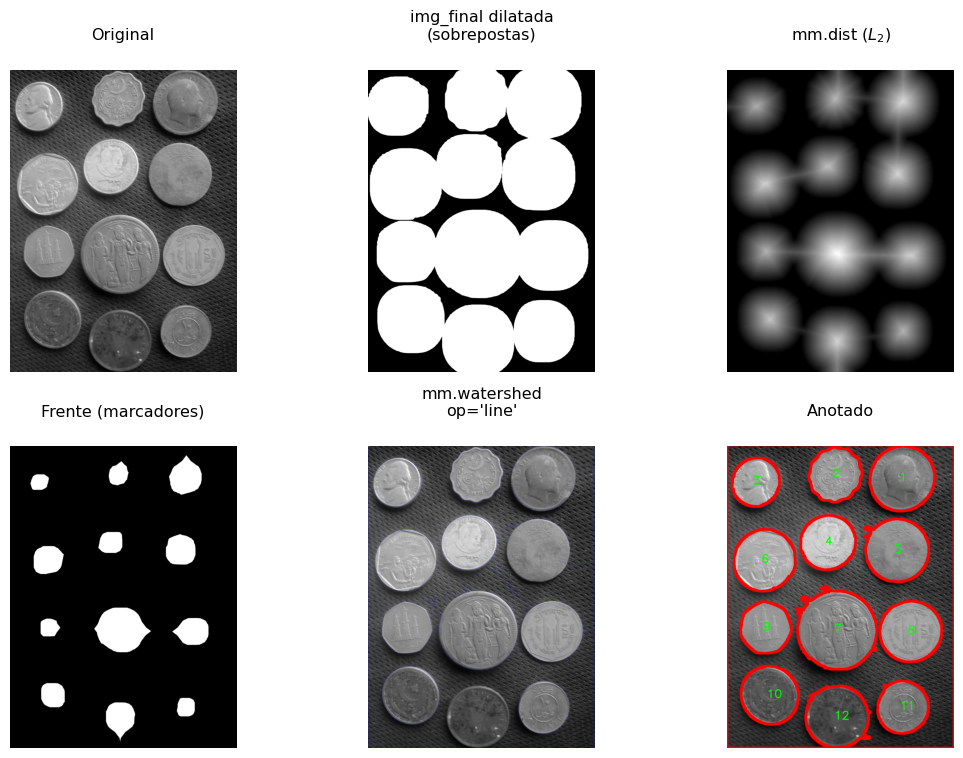

**Figura 4.18:** Pipeline Watershed para separação de moedas sobrepostas: da máscara binária dilatada até os contornos finais anotados sobre a imagem original.


In [ ]:
img_base = img_coins_gray

# Dilatar img_final para conectar moedas (simula sobreposição real)
img_sobrepostas = mm.dil(img_final, mm.sebox(40))

# ── Etapas 1-2 ───────────────────────────────────────────────────────────────
kernel  = mm.sebox(2)
opening = mm.open(opening, kernel)

# ── Etapas 2-4 ───────────────────────────────────────────────────────────────
bg      = cv2.dilate(opening, kernel, iterations=3)
dist    = mm.dist(opening)
dist_vis = cv2.normalize(dist.astype(np.float32), None, 0, 255,
                         cv2.NORM_MINMAX).astype(np.uint8)

_, fg   = cv2.threshold(dist.astype(np.float32), 0.5 * dist.max(), 255, 0)
fg      = fg.astype(np.uint8)
unknown = cv2.subtract(bg, fg)

# ── Etapas 5-6 ───────────────────────────────────────────────────────────────
n_markers, markers = cv2.connectedComponents(fg)
markers = markers + 1
markers[unknown == 255] = 0

img_bgr = cv2.cvtColor(img_base, cv2.COLOR_GRAY2BGR)
ws_line = mm.watershed(img_bgr.copy(), fg, op='line')

# Imagem anotada
markers_ann = markers.copy()
img_annotated = cv2.cvtColor(img_base, cv2.COLOR_GRAY2BGR)
cv2.watershed(img_annotated, markers_ann)

for m in range(2, n_markers + 1):
    mask = (markers_ann == m).astype(np.uint8)
    if mask.sum() < 500: continue
    cx = int(np.mean(np.where(mask)[1]))
    cy = int(np.mean(np.where(mask)[0]))
    cv2.putText(img_annotated, str(m - 1), (cx - 25, cy + 20),
                cv2.FONT_HERSHEY_SIMPLEX, 3.2, (0, 255, 0), 8, cv2.LINE_AA)

mask_ann = (markers_ann == -1).astype(np.uint8)
mask_ann = cv2.dilate(mask_ann, np.ones((11, 11), np.uint8), iterations=2)
img_annotated[mask_ann == 1] = [0, 0, 255]
img_annotated = cv2.cvtColor(img_annotated, cv2.COLOR_BGR2RGB)
ws_line_rgb   = cv2.cvtColor(ws_line, cv2.COLOR_BGR2RGB)

print(f"Objetos detectados: {n_markers - 1}")

mm.show(
    [img_base, img_sobrepostas, dist_vis, fg, ws_line_rgb, img_annotated],
    titles=[
        "Original", "img_final dilatada\n(sobrepostas)",
        "mm.dist ($L_2$)", "Frente (marcadores)",
        "mm.watershed\nop='line'", "Anotado"
    ],
    cols=3, rows=2, figsize=(12, 8)
)

## 4.5 Extração de Componentes e Descritores de Forma

Após segmentação e refinamento morfológico, o próximo passo é **rotular** cada região
conexa e extrair suas propriedades. Um **componente conexo** é um conjunto máximo de
pixels brancos mutuamente conectados (4- ou 8-conectividade).

Duas funções do OpenCV abordam esse problema por ângulos complementares:

| | `connectedComponentsWithStats` | `findContours` |
|---|---|---|
| **Retorna** | rótulo por pixel + estatísticas | sequência de pontos da borda |
| **Descritores diretos** | área, bounding box, centróide | perímetro, forma, hierarquia |
| **Objetos em contato** | tende a fundir regiões conectadas | tende a retornar um único contorno externo |
| **Uso típico** | contar, filtrar, colorir regiões | análise de forma, polígonos |

### 4.5.1 connectedComponentsWithStats

A [Figura 4.19](#fig-04-componentes) demonstra a extração na imagem de moedas.

In [ ]:
# 1. Rotulagem e estatísticas
n, labels, stats, centroids = cv2.connectedComponentsWithStats(
    img_final, connectivity=8
)

# 2. Coloração dos componentes
np.random.seed(4)
colors    = np.random.randint(50, 255, (n, 3), dtype=np.uint8)
colors[0] = [0, 0, 0]                          # fundo preto
img_colored   = colors[labels]
img_annotated = img_colored.copy()

# 3. Tabela de descritores
print(f"Componentes detectados (excluindo fundo): {n - 1}")
print(f"\n{'ID':>4} {'Área':>8} {'cx':>6} {'cy':>6} {'w':>6} {'h':>6}")
print("-" * 42)
for i in range(1, n):
    area = stats[i, cv2.CC_STAT_AREA]
    cx, cy = int(centroids[i, 0]), int(centroids[i, 1])
    w, h   = stats[i, cv2.CC_STAT_WIDTH], stats[i, cv2.CC_STAT_HEIGHT]
    print(f"{i:>4} {area:>8} {cx:>6} {cy:>6} {w:>6} {h:>6}")
    for cor, esp in [((0,0,0), 10), ((255,0,0), 5)]:
        cv2.putText(img_annotated, f"{i}: {area}",
                    (cx - 150, cy + 18),
                    cv2.FONT_HERSHEY_SIMPLEX, 2.0, cor, esp, cv2.LINE_AA)

mm.show(
    [img_coins_gray, img_final, img_colored, img_annotated],
    titles=["Original", "Segmentação Final", "Componentes Conexos", "Áreas Anotadas"],
    cols=4, figsize=(18, 6)
)

**Figura 4.19:** Componentes conexos extraídos após o pipeline CLAHE → Otsu → limpeza morfológica. Cada objeto é colorido com cor distinta e anotado com sua área em pixels.


### 4.5.2 Descritores de Forma

`findContours` opera sobre a **borda** dos objetos, retornando para cada um a sequência
de pontos que define seu contorno. Isso permite calcular descritores geométricos que
`connectedComponentsWithStats` não fornece diretamente:

- **Perímetro** (`cv2.arcLength`)  
- **Circularidade** $C = 4\pi A / P^2$ — vale 1 para círculo perfeito e é sensível a irregularidades de borda e ruídos no contorno
- **Aproximação poligonal** (`cv2.approxPolyDP`)  
- **Convex hull** e **convexidade**  
- **Hierarquia** — relação pai/filho entre contornos (objeto com buraco interno)

A [Figura 4.20](#fig-04-contornos) exibe os mesmos objetos com circularidade anotada.

In [ ]:
contornos, hierarquia = cv2.findContours(
    img_final, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE
)

img_contornos  = cv2.cvtColor(img_coins_gray, cv2.COLOR_GRAY2BGR)
img_circulares = img_contornos.copy()

print(f"Contornos detectados: {len(contornos)}")
print(f"\n{'ID':>4} {'Área':>8} {'Perímetro':>10} {'Circularidade':>14}")
print("-" * 42)

for i, cnt in enumerate(contornos, start=1):
    area  = cv2.contourArea(cnt)
    perim = cv2.arcLength(cnt, closed=True)
    circ  = (4 * np.pi * area / perim**2) if perim > 0 else 0
    M     = cv2.moments(cnt)
    cx    = int(M["m10"] / M["m00"]) if M["m00"] > 0 else 0
    cy    = int(M["m01"] / M["m00"]) if M["m00"] > 0 else 0

    print(f"{i:>4} {area:>8.0f} {perim:>10.1f} {circ:>14.3f}")

    cv2.drawContours(img_contornos,  [cnt], -1, (0, 255, 0), 3)
    cv2.drawContours(img_circulares, [cnt], -1, (0, 255, 0), 3)
    for cor, esp in [((0,0,0), 8), ((255,0,0), 3)]:
        cv2.putText(img_circulares, f"{circ:.2f}",
                    (cx - 80, cy + 15),
                    cv2.FONT_HERSHEY_SIMPLEX, 3.6, cor, esp, cv2.LINE_AA)

mm.show(
    [img_final, img_contornos, img_circulares],
    titles=["Segmentação Final", "Contornos", "Circularidade"],
    cols=3, figsize=(18, 6)
)

**Figura 4.20:** Contornos extraídos com findContours. Cada moeda é anotada com sua circularidade — valores próximos de 1 confirmam forma circular.


### 4.5.3 Segmentação por *K-Means*

O ***k-means*** agrupa pixels em $k$ *clusters* minimizando a inércia (soma das distâncias quadráticas intra-cluster):

<a id="eq-04-kmeans"></a>
$$
J = \sum_{i=1}^{k}\sum_{x \in C_i} \|x - \mu_i\|^2 \tag{4.14}
$$


O algoritmo itera entre dois passos até que os centróides variem muito pouco ou seja atingido o número máximo de iterações: **(1) atribuição** — cada pixel ao centróide mais próximo; **(2) atualização** — cada centróide recalculado como média dos pixels atribuídos. A escolha de $k$ é auxiliada pelo **método do cotovelo**: plota-se $J$ em função de $k$ e identifica-se o ponto de inflexão (cotovelo), a partir do qual o aumento de $k$ traz reduções apenas marginais na inércia, evitando o sobreajuste (*overfitting*).

A [Figura 4.21](#fig-04-kmeans-cotovelo) mostra o método do cotovelo e a [Figura 4.22](#fig-04-kmeans) a segmentação resultante:

In [ ]:
pixels   = img_coins_gray.reshape(-1, 1).astype(np.float32)
inercias = []
ks       = list(range(2, 9))
resultados = []  # guarda (labels, centers) para reusar no mm.show

for k in ks:
    criteria = (cv2.TERM_CRITERIA_EPS + cv2.TERM_CRITERIA_MAX_ITER, 100, 0.2)
    _, labels, centers = cv2.kmeans(pixels, k, None, criteria, 5, cv2.KMEANS_RANDOM_CENTERS)
    # inércia: distância de cada pixel ao centróide atribuído
    dists = (pixels - centers[labels.flatten()])**2
    inercias.append(float(dists.sum()))
    resultados.append((labels, centers))

imgs, titles = [], []
for k, inercia, (labels, centers) in zip(ks, inercias, resultados):
    seg = centers[labels.flatten()].reshape(img_coins_gray.shape).astype(np.uint8)
    imgs   += [seg]
    titles += [f"k={k}  J={inercia:.2e}"]

mm.show(imgs, titles=titles, cols=4, rows=2, figsize=(12, 12))

**Figura 4.21:** Método do cotovelo: inércia J em função de k para a imagem de moedas. O ponto de inflexão sugere o k ótimo.


In [ ]:
def kmeans_seg(img, k):
    pixels   = img.reshape(-1,1).astype(np.float32)
    criteria = (cv2.TERM_CRITERIA_EPS + cv2.TERM_CRITERIA_MAX_ITER, 100, 0.2)
    _, labels, centers = cv2.kmeans(pixels, k, None, criteria, 5, cv2.KMEANS_RANDOM_CENTERS)
    return centers[labels.flatten()].reshape(img.shape).astype(np.uint8)

imgs_km   = [img_coins_gray] + [kmeans_seg(img_coins_gray, k) for k in [2, 4, 6]]
titles_km = ["Original"] + [f"k-means k={k}" for k in [2, 4, 6]]
mm.show(imgs_km, titles=titles_km, cols=4, figsize=(18, 6))

**Figura 4.22:** Segmentação * da imagem das moedas com k=2, 4 e 6 clusters. Cada região é preenchida com a intensidade média do seu centróide.


## 4.6 Aplicação Prática: Pipeline Completo de Contagem

Reunindo as técnicas do capítulo em um *pipeline* de **contagem automática de moedas**, problema clássico em controle de qualidade industrial e visão robótica.

> ### 📝 Avaliação: IoU (*Intersection over Union*)
>
> Para avaliar a qualidade da segmentação com máscara de referência (*ground truth*):
> <a id="eq-04-iou"></a>
$$
> \text{IoU} = \frac{|A \cap B|}{|A \cup B|}
> \tag{4.15}
$$

> onde $A$ é a segmentação obtida e $B$ é a referência. $\text{IoU} = 1$ indica segmentação perfeita. Para múltiplos objetos. Em aplicações de detecção de objetos, frequentemente utiliza-se $\text{IoU} \geq 0.5$ como critério mínimo de correspondência..

## 4.7 Resumo

Neste capítulo foram apresentadas as técnicas de segmentação e morfologia matemática, fechando o ciclo do PDI no domínio espacial:

* **Otsu e pré-processamento:** O algoritmo CLAHE provou-se superior na indução de separação bimodal no histograma ($\sigma_B^2 \approx 2{,}47 \times 10^3$, $T^* = 122$), simplificando a binarização de imagens com iluminação não uniforme.
* **Erosão e dilatação:** Operadores morfológicos fundamentais baseados na busca por mínimo/máximo local em uma vizinhança definida pelo elemento estruturante $B$. São duais pelo complemento e implementados no pacote prático como `mm.ero` e `mm.dil`.
* **Abertura e fechamento:** Composições estritas (erosão $\to$ dilatação e dilatação $\to$ erosão) com propriedades de idempotência, fundamentais para suprimir ruídos externos e preencher lacunas internas, respectivamente.
* **Reconstrução morfológica:** Operação geodésica iterativa que propaga um marcador estritamente dentro dos limites de uma máscara. Constitui o motor por trás de filtros que não deformam a geometria dos objetos, como `mm.clohole` e `mm.edgeoff`.
* **Pipeline de limpeza binária:** Fluxo consolidado como: CLAHE $\to$ Otsu $\to$ abertura (filtra ruído de fundo) $\to$ `mm.clohole` (preenche cavidades) $\to$ abertura restrita (suaviza artefatos espúrios) $\to$ `mm.edgeoff` (filtra objetos tocando a borda).
* **Morfologia em tons de cinza:** Extensão algébrica com mínimo/máximo ponderado, viabilizando o gradiente morfológico e filtros de *top-hat* para extração de topologia.
* **Componentes conexos e descritores:** Rotulagem espacial (`cv2.connectedComponentsWithStats`) acoplada à extração de fronteiras ativas, gerando métricas como área, circularidade e centróides.
* ***Watershed* e *k-means*:** Algoritmos complementares; o primeiro focado na separação topográfica de objetos espacialmente sobrepostos, e o segundo no agrupamento estatístico por similaridade de intensidades.

O Capítulo 5 abordará o **domínio da frequência** (Transformada de Fourier, filtragem espectral) e os fundamentos de **compressão de imagens** (DCT, JPEG, *wavelets*).

## 4.8 🤖 Uso do NotebookLM como Tutor Complementar

Nesta edição, incentiva-se o uso do **NotebookLM** como ferramenta complementar de aprendizagem. Baseado em inteligência artificial, o sistema utiliza exclusivamente os documentos fornecidos pelo autor como fonte de conhecimento, produzindo respostas alinhadas ao conteúdo e à abordagem adotada ao longo do livro.

> ### ❗ 🎓 Estude com o Tutor Inteligente
>
> [🚀 ACESSAR NOTEBOOKLM: CAPÍTULO 04](https://notebooklm.google.com/notebook/cap04)

## 4.9 Lista de Exercícios

1. **(10%)** Implemente manualmente o critério de Otsu sem usar `cv2.threshold`: calcule $\sigma_B^2(T)$ para todos os $T \in [0,255]$ usando `mm.hist`, identifique $T^*$ e compare com o valor do OpenCV. Plote $\sigma_B^2$ em função de $T$ e marque o máximo.
2. **(15%)** Aplique limiarização adaptativa com blocos de tamanho 11, 31 e 51 à imagem Lena com gradiente de iluminação simulado (`np.linspace` adicionado à imagem). Compare visualmente com Otsu global e explique por que a adaptativa é superior nesse cenário.
3. **(15%)** Execute o *pipeline* *watershed* na imagem de moedas variando o limiar da transformada de distância ($0.3$, $0.5$, $0.7 \times$ máximo). Explique como esse parâmetro afeta a separação de objetos sobrepostos e a criação de sobre-segmentação.
4. **(15%)** Usando `mm.drawImage` e `mm.drawImageKernel`, crie uma demonstração visual passo a passo da erosão de uma imagem binária 7×7 com elemento estruturante 3×3 quadrado — mostrando para cada pixel central se o elemento estruturante está completamente contido em $A$ ou não.
5. **(15%)** Demonstre a **dualidade erosão–dilatação** experimentalmente com `mm.ero`, `mm.dil` e `mm.bnot`: verifique que $(A \ominus B)^c = A^c \oplus \hat{B}$. Calcule a diferença pixel a pixel entre os dois lados e exiba com `mm.histImg`.
6. **(15%)** Implemente o **gradiente morfológico** manualmente usando `mm.ero` e `mm.dil` e compare com `cv2.morphologyEx(img, cv2.MORPH_GRADIENT, B)`. Aplique com elementos estruturantes de forma e tamanho diferentes (quadrado 3×3, disco 5×5, linha 1×9) e explique as diferenças na resposta de bordas.
7. **(15%)** Construa um *pipeline* completo para contar e classificar as moedas por tamanho (pequena, média, grande) usando área e circularidade como critérios. Calcule o **IoU** entre sua segmentação e uma máscara de referência criada manualmente. Apresente os resultados em tabela e com `mm.show` em grade.

## Referências do Capítulo


A fundamentação teórica deste capítulo baseia-se nas seguintes obras:
* Gonzalez e Woods (2018) para os conceitos de segmentação, limiarização de Otsu, morfologia matemática e descritores de forma.
* Matheron (1975) e Serra (1982) para a fundamentação teórica original, formulação algébrica e desenvolvimento da Morfologia Matemática.
* Szeliski (2022) para *watershed*, *k-means* aplicado a imagens e avaliação quantitativa com a métrica IoU.
* Bradski e Kaehler (2008) para a implementação prática com a biblioteca OpenCV (`cv2.watershed`, `cv2.connectedComponentsWithStats`) e o pacote didático `morph.py`.

BRADSKI, Gary; KAEHLER, Adrian. **Learning OpenCV: Computer vision with the OpenCV library**. " O'Reilly Media, Inc.", 2008.

GONZALEZ, R. C.; WOODS, R. E. **Digital Image Processing**. New York, Pearson, 2018.

MATHERON, G. **Random Sets and Integral Geometry**. New York, John Wiley \& Sons, 1975.

SERRA, Jean. **Image Analysis and Mathematical Morphology**. London, Academic Press, 1982.

SZELISKI, Richard. **Computer Vision: Algorithms and Applications**. Cham, Switzerland, Springer, 2022.

*Referência não encontrada para: staticmethod*